# Importing Libraries:

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Feature selection / inspection
from sklearn.inspection import permutation_importance

# Saving models
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# Importing Dataset:

In [5]:
# Excel file path
file_path = "EduPro Online Platform.xlsx"

# Load all sheets
users = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Users")
teachers = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Teachers")
courses = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Courses")
transactions = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Transactions")

print("All sheets loaded successfully.")

All sheets loaded successfully.


In [6]:
print("Users shape:", users.shape)
print("Teachers shape:", teachers.shape)
print("Courses shape:", courses.shape)
print("Transactions shape:", transactions.shape)

Users shape: (3000, 5)
Teachers shape: (60, 7)
Courses shape: (60, 8)
Transactions shape: (10000, 7)


In [7]:
print("USERS")
display(users.head())

print("\nTEACHERS")
display(teachers.head())

print("\nCOURSES")
display(courses.head())

print("\nTRANSACTIONS")
display(transactions.head())

USERS


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com



TEACHERS


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11



COURSES


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28



TRANSACTIONS


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [8]:
print("Users columns:")
print(users.columns.tolist())

print("\nTeachers columns:")
print(teachers.columns.tolist())

print("\nCourses columns:")
print(courses.columns.tolist())

print("\nTransactions columns:")
print(transactions.columns.tolist())

Users columns:
['UserID', 'UserName', 'Age', 'Gender', 'Email']

Teachers columns:
['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating']

Courses columns:
['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']

Transactions columns:
['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID']


# Data Preprocessing:

In [9]:
# check data type
print("Teachers Data Types")
display(teachers.dtypes)

print("\nCourses Data Types")
display(courses.dtypes)

print("\nTransactions Data Types")
display(transactions.dtypes)

Teachers Data Types


TeacherID             object
TeacherName           object
Age                    int64
Gender                object
Expertise             object
YearsOfExperience      int64
TeacherRating        float64
dtype: object


Courses Data Types


CourseID           object
CourseName         object
CourseCategory     object
CourseType         object
CourseLevel        object
CoursePrice       float64
CourseDuration    float64
CourseRating      float64
dtype: object


Transactions Data Types


TransactionID              object
UserID                     object
CourseID                   object
TransactionDate    datetime64[ns]
Amount                    float64
PaymentMethod              object
TeacherID                  object
dtype: object

In [10]:
# Check misssing values:
print("Missing Values - Users")
display(users.isnull().sum())

print("\nMissing Values - Teachers")
display(teachers.isnull().sum())

print("\nMissing Values - Courses")
display(courses.isnull().sum())

print("\nMissing Values - Transactions")
display(transactions.isnull().sum())

Missing Values - Users


UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64


Missing Values - Teachers


TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


Missing Values - Courses


CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64


Missing Values - Transactions


TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

In [11]:
# Check for duplicate rows
print("Duplicate rows")

print("Users:", users.duplicated().sum())
print("Teachers:", teachers.duplicated().sum())
print("Courses:", courses.duplicated().sum())
print("Transactions:", transactions.duplicated().sum())

Duplicate rows
Users: 0
Teachers: 0
Courses: 0
Transactions: 0


In [12]:
# Duplicate ID checks

print("Duplicate User IDs:", users["UserID"].duplicated().sum())
print("Duplicate Teacher IDs:", teachers["TeacherID"].duplicated().sum())
print("Duplicate Course IDs:", courses["CourseID"].duplicated().sum())
print("Duplicate Transaction IDs:", transactions["TransactionID"].duplicated().sum())

Duplicate User IDs: 0
Duplicate Teacher IDs: 0
Duplicate Course IDs: 0
Duplicate Transaction IDs: 0


In [13]:
# Statistical Summary

print("Teacher numerical summary")
display(teachers.describe())

print("\nCourse numerical summary")
display(courses.describe())

print("\nTransaction numerical summary")
display(transactions.describe())

Teacher numerical summary


,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000



Course numerical summary


,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000



Transaction numerical summary


,TransactionDate,Amount
count,10000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347
min,2025-01-01 00:00:00,0.000000
25%,2025-04-02 00:00:00,0.000000
50%,2025-06-30 00:00:00,0.000000
75%,2025-09-28 00:00:00,119.040000
max,2025-12-30 00:00:00,490.900000
std,NaN,152.063524


In [14]:
# Data Cleaning:
# Create copies so original data remains unchanged

teachers_clean = teachers.copy()
courses_clean = courses.copy()
transactions_clean = transactions.copy()

# Convert date
transactions_clean["TransactionDate"] = pd.to_datetime(
    transactions_clean["TransactionDate"],
    errors="coerce"
)

# Remove completely duplicated rows
teachers_clean = teachers_clean.drop_duplicates()
courses_clean = courses_clean.drop_duplicates()
transactions_clean = transactions_clean.drop_duplicates()

# Handle numeric missing values
teachers_clean["YearsOfExperience"] = teachers_clean["YearsOfExperience"].fillna(
    teachers_clean["YearsOfExperience"].median()
)

teachers_clean["TeacherRating"] = teachers_clean["TeacherRating"].fillna(
    teachers_clean["TeacherRating"].median()
)

courses_clean["CoursePrice"] = courses_clean["CoursePrice"].fillna(0)

courses_clean["CourseDuration"] = courses_clean["CourseDuration"].fillna(
    courses_clean["CourseDuration"].median()
)

courses_clean["CourseRating"] = courses_clean["CourseRating"].fillna(
    courses_clean["CourseRating"].median()
)

transactions_clean["Amount"] = transactions_clean["Amount"].fillna(0)

print("Data cleaning completed.")

Data cleaning completed.


In [15]:
# Merge Courses + Transactions (Transactions contain multiple records per course)
# Therefore, we first calculate course-level historical performance.

course_transaction_summary = (
    transactions_clean
    .groupby("CourseID")
    .agg(
        Enrollment_Count=("TransactionID", "count"),
        Course_Revenue=("Amount", "sum"),
        Average_Transaction_Amount=("Amount", "mean"),
        Unique_Learners=("UserID", "nunique"),
        Transaction_Count=("TransactionID", "count")
    )
    .reset_index()
)

display(course_transaction_summary.head())

# Course_Revenue mostly 0 hai. Iska matlab grouping code problem nahi hai — problem Amount column ke data mein hai

,CourseID,Enrollment_Count,Course_Revenue,Average_Transaction_Amount,Unique_Learners,Transaction_Count
0,CR00001,164,77453.92,472.28,164,164
1,CR00002,149,0.00,0.00,149,149
2,CR00003,173,0.00,0.00,173,173
3,CR00004,154,0.00,0.00,154,154
4,CR00005,166,0.00,0.00,166,166


In [16]:
# Check Amount values
print(transactions_clean["Amount"].dtype)

display(
    transactions_clean[
        ["CourseID", "Amount"]
    ].head(20)
)

float64


,CourseID,Amount
0,CR00016,0.00
1,CR00037,0.00
2,CR00019,0.00
3,CR00048,0.00
4,CR00060,0.00
5,CR00042,0.00
6,CR00017,0.00
7,CR00025,299.57
8,CR00003,0.00
9,CR00032,0.00


In [17]:
# Har CourseID ka Amount check karo
amount_check = (
    transactions_clean
    .groupby("CourseID")["Amount"]
    .agg(
        Count="count",
        Sum="sum",
        Mean="mean",
        Min="min",
        Max="max",
        Zero_Count=lambda x: (x == 0).sum()
    )
    .reset_index()
)

display(amount_check.head(20))

,CourseID,Count,Sum,Mean,Min,Max,Zero_Count
0,CR00001,164,77453.92,472.28,472.28,472.28,0
1,CR00002,149,0.00,0.00,0.00,0.00,149
2,CR00003,173,0.00,0.00,0.00,0.00,173
3,CR00004,154,0.00,0.00,0.00,0.00,154
4,CR00005,166,0.00,0.00,0.00,0.00,166
5,CR00006,156,43113.72,276.37,276.37,276.37,0
6,CR00007,178,0.00,0.00,0.00,0.00,178
7,CR00008,158,0.00,0.00,0.00,0.00,158
8,CR00009,155,0.00,0.00,0.00,0.00,155
9,CR00010,180,0.00,0.00,0.00,0.00,180


In [18]:
# Check karo kitne Amount zero hain
print("Total transactions:", len(transactions_clean))
print("Zero Amount:", (transactions_clean["Amount"] == 0).sum())
print("Missing Amount:", transactions_clean["Amount"].isna().sum())

Total transactions: 10000
Zero Amount: 6403
Missing Amount: 0


In [19]:
# Amount ko numeric properly convert karo (Agar Amount ka dtype object aa raha hai)

transactions_clean["Amount"] = (
    transactions_clean["Amount"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.strip()
)

transactions_clean["Amount"] = pd.to_numeric(
    transactions_clean["Amount"],
    errors="coerce"
)

In [20]:
# check:
display(
    transactions_clean[
        ["CourseID", "Amount"]
    ].head(20)
)

,CourseID,Amount
0,CR00016,0.00
1,CR00037,0.00
2,CR00019,0.00
3,CR00048,0.00
4,CR00060,0.00
5,CR00042,0.00
6,CR00017,0.00
7,CR00025,299.57
8,CR00003,0.00
9,CR00032,0.00


In [21]:
#b Dataset itself mein 6,403 transactions free/zero-value transactions hain. Hum 0 ko missing value nahi maanenge. Because
# Amount = 0 can legitimately mean a free course, promotional enrollment, scholarship, trial, or non-paid transaction.

# Lekin ek additional feature banao: Paid_Enrollment_Count

course_transaction_summary = (
    transactions_clean
    .groupby("CourseID")
    .agg(
        Enrollment_Count=("TransactionID", "count"),  # Har course mein kitne transaction/enrollment records hain
        Course_Revenue=("Amount", "sum"),  # Course se total kitna revenue generate hua
        Average_Transaction_Amount=("Amount", "mean"),  # Ek transaction par average kitna amount pay kiya gaya
        Unique_Learners=("UserID", "nunique"),  # number of unique values
        Transaction_Count=("TransactionID", "count"),  # total transaction records count karta hai
        Paid_Enrollment_Count=("Amount", lambda x: (x > 0).sum())  # 'x' Har course ke Amount values h. x > 0 check karega: True ko 1 aur False ko 0 ke form mein count karta hai
    )
    .reset_index()
)

course_transaction_summary["Free_Enrollment_Count"] = (
    course_transaction_summary["Enrollment_Count"]
    - course_transaction_summary["Paid_Enrollment_Count"]
)

course_transaction_summary["Paid_Enrollment_Rate"] = (  # Total enrollments mein se kitne percent paid hain
    course_transaction_summary["Paid_Enrollment_Count"]
    / course_transaction_summary["Enrollment_Count"]
    * 100
)

display(course_transaction_summary.head(20))

,CourseID,Enrollment_Count,Course_Revenue,Average_Transaction_Amount,Unique_Learners,Transaction_Count,Paid_Enrollment_Count,Free_Enrollment_Count,Paid_Enrollment_Rate
0,CR00001,164,77453.92,472.28,164,164,164,0,100.0
1,CR00002,149,0.00,0.00,149,149,0,149,0.0
2,CR00003,173,0.00,0.00,173,173,0,173,0.0
3,CR00004,154,0.00,0.00,154,154,0,154,0.0
4,CR00005,166,0.00,0.00,166,166,0,166,0.0
5,CR00006,156,43113.72,276.37,156,156,156,0,100.0
6,CR00007,178,0.00,0.00,178,178,0,178,0.0
7,CR00008,158,0.00,0.00,158,158,0,158,0.0
8,CR00009,155,0.00,0.00,155,155,0,155,0.0
9,CR00010,180,0.00,0.00,180,180,0,180,0.0


In [22]:
# Merge Course Information

course_data = courses_clean.merge(
    course_transaction_summary,
    on="CourseID",
    how="left"
)

# Courses without transactions
course_data["Enrollment_Count"] = course_data["Enrollment_Count"].fillna(0)
course_data["Course_Revenue"] = course_data["Course_Revenue"].fillna(0)
course_data["Average_Transaction_Amount"] = course_data[
    "Average_Transaction_Amount"
].fillna(0)

course_data["Unique_Learners"] = course_data["Unique_Learners"].fillna(0)
course_data["Transaction_Count"] = course_data["Transaction_Count"].fillna(0)

display(course_data.head())

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,Enrollment_Count,Course_Revenue,Average_Transaction_Amount,Unique_Learners,Transaction_Count,Paid_Enrollment_Count,Free_Enrollment_Count,Paid_Enrollment_Rate
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92,472.28,164,164,164,0,100.0
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00,0.00,149,149,0,149,0.0
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00,0.00,173,173,0,173,0.0
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00,0.00,154,154,0,154,0.0
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00,0.00,166,166,0,166,0.0


In [23]:
# Add Teacher Information Because transactions have TeacherID, we determine the main/associated teacher for each course

# Find the most frequently associated teacher for each course
course_teacher = (
    transactions_clean
    .groupby(["CourseID", "TeacherID"])
    .size()
    .reset_index(name="Transaction_Count")
    .sort_values(
        ["CourseID", "Transaction_Count"],
        ascending=[True, False]
    )
)

course_teacher = (
    course_teacher
    .drop_duplicates("CourseID")
    [["CourseID", "TeacherID"]]
)

display(course_teacher.head())

,CourseID,TeacherID
20,CR00001,TC00042
36,CR00002,TC00042
65,CR00003,TC00040
91,CR00004,TC00040
117,CR00005,TC00040


In [24]:
# Merge teacher ID with course data
course_data = course_data.merge(
    course_teacher,
    on="CourseID",
    how="left"
)

# Merge teacher information
course_data = course_data.merge(
    teachers_clean[
        [
            "TeacherID",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating"
        ]
    ],
    on="TeacherID",
    how="left"
)

display(course_data.head())

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,Enrollment_Count,Course_Revenue,Average_Transaction_Amount,Unique_Learners,Transaction_Count,Paid_Enrollment_Count,Free_Enrollment_Count,Paid_Enrollment_Rate,TeacherID,Expertise,YearsOfExperience,TeacherRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92,472.28,164,164,164,0,100.0,TC00042,Machine Learning,21,4.97
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00,0.00,149,149,0,149,0.0,TC00042,Machine Learning,21,4.97
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00,0.00,173,173,0,173,0.0,TC00040,Cybersecurity,24,4.58
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00,0.00,154,154,0,154,0.0,TC00040,Cybersecurity,24,4.58
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00,0.00,166,166,0,166,0.0,TC00040,Cybersecurity,24,4.58


In [25]:
# Check Final Dataset

print("Final course-level dataset shape:", course_data.shape)

display(course_data.head())

print("\nColumns:")
print(course_data.columns.tolist())

Final course-level dataset shape: (60, 20)


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,Enrollment_Count,Course_Revenue,Average_Transaction_Amount,Unique_Learners,Transaction_Count,Paid_Enrollment_Count,Free_Enrollment_Count,Paid_Enrollment_Rate,TeacherID,Expertise,YearsOfExperience,TeacherRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92,472.28,164,164,164,0,100.0,TC00042,Machine Learning,21,4.97
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00,0.00,149,149,0,149,0.0,TC00042,Machine Learning,21,4.97
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00,0.00,173,173,0,173,0.0,TC00040,Cybersecurity,24,4.58
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00,0.00,154,154,0,154,0.0,TC00040,Cybersecurity,24,4.58
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00,0.00,166,166,0,166,0.0,TC00040,Cybersecurity,24,4.58



Columns:
['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'Enrollment_Count', 'Course_Revenue', 'Average_Transaction_Amount', 'Unique_Learners', 'Transaction_Count', 'Paid_Enrollment_Count', 'Free_Enrollment_Count', 'Paid_Enrollment_Rate', 'TeacherID', 'Expertise', 'YearsOfExperience', 'TeacherRating']


In [26]:
# Revenue per Enrollment

course_data["Revenue_Per_Enrollment"] = np.where(
    course_data["Enrollment_Count"] > 0,
    course_data["Course_Revenue"] / course_data["Enrollment_Count"],
    0
)

display(
    course_data[
        [
            "CourseID",
            "CourseName",
            "Enrollment_Count",
            "Course_Revenue",
            "Revenue_Per_Enrollment"
        ]
    ].head(10)
)

,CourseID,CourseName,Enrollment_Count,Course_Revenue,Revenue_Per_Enrollment
0,CR00001,Python Basics,164,77453.92,472.28
1,CR00002,Java Programming,149,0.00,0.00
2,CR00003,C++ for Beginners,173,0.00,0.00
3,CR00004,Advanced Python,154,0.00,0.00
4,CR00005,Full Stack Development,166,0.00,0.00
5,CR00006,Graphic Design Basics,156,43113.72,276.37
6,CR00007,UI/UX Design,178,0.00,0.00
7,CR00008,Photoshop Mastery,158,0.00,0.00
8,CR00009,Web Design Fundamentals,155,0.00,0.00
9,CR00010,3D Modeling,180,0.00,0.00


# Feature Engineering:

In [27]:
# Price Band

course_data["Price_Band"] = pd.cut( # pd.cut() numerical values ko ranges/categories mein convert karta hai.
                                    # Humhare case mein CoursePrice ko 4 categories mein divide kiya gaya hai
    course_data["CoursePrice"],
    bins=[-1, 0, 300, 700, np.inf],  # np.inf ka matlab infinity, yani ₹700 se upar ki koi bhi price
                                     # Ye boundaries hain:
                                     # -1 ── 0 ───── 300 ───── 700 ───── ∞
                                     #      │         │          │
                                     #     Free      Low       Medium     High
    labels=["Free", "Low", "Medium", "High"]
)

course_data["Price_Band"].value_counts()  # Ye count karega ki kitne courses Free, Low, Medium aur High price category mein hain

Price_Band
Free      38
Low       13
Medium     9
High       0
Name: count, dtype: int64

In [28]:
# Duration Bucket

course_data["Duration_Bucket"] = pd.cut(
    course_data["CourseDuration"],
    bins=[-np.inf, 10, 25, 50, np.inf],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

course_data["Duration_Bucket"].value_counts()

Duration_Bucket
Long         32
Medium       16
Short        12
Very Long     0
Name: count, dtype: int64

In [29]:
# Rating Tier

course_data["Rating_Tier"] = pd.cut(
    course_data["CourseRating"],
    bins=[0, 2.5, 3.5, 4.25, 5],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ],
    include_lowest=True
)

course_data["Rating_Tier"].value_counts()

Rating_Tier
Low          20
Average      15
Excellent    13
Good         12
Name: count, dtype: int64

In [30]:
# Teacher Experience Bucket

course_data["Experience_Bucket"] = pd.cut(
    course_data["YearsOfExperience"],
    bins=[-1, 2, 5, 10, np.inf],
    labels=[
        "Beginner",
        "Intermediate",
        "Experienced",
        "Highly Experienced"
    ]
)

course_data["Experience_Bucket"].value_counts()

Experience_Bucket
Highly Experienced    60
Beginner               0
Intermediate           0
Experienced            0
Name: count, dtype: int64

In [31]:
# Expertise Match Score (We compare course category and teacher expertise)

course_data["Expertise_Match_Score"] = (
    course_data["CourseCategory"]
    .astype(str)
    .str.lower()  # CourseCategory ko string mein convert karke lowercase karta hai. Same kaam: Expertise column ke saath hota hai
    ==  # '==' Dono columns ko row-by-row compare karta hai
    course_data["Expertise"]
    .astype(str)
    .str.lower()
).astype(int)  # Boolean values: True  → 1 False → 0

course_data["Expertise_Match_Score"].value_counts()

# Because course category and teacher expertise may use different naming conventions, a direct string match can be restrictive. 
# Therefore, we keep this as a transparent engineered feature rather than claiming that 0 means the teacher is unqualified.

# 50 courses mein Category aur Expertise match nahi kar rahe (0)
# 10 courses mein Category aur Expertise exact match kar rahe hain (1)

Expertise_Match_Score
0    50
1    10
Name: count, dtype: int64

In [32]:
# Historical Transaction Features

transactions_clean["Transaction_Year"] = (  # TransactionDate se year extract karta hai
    transactions_clean["TransactionDate"].dt.year
)

transactions_clean["Transaction_Month"] = (  # TransactionDate se month extract karta hai
    transactions_clean["TransactionDate"].dt.month
)

transactions_clean["Transaction_Quarter"] = (  # Year ko 4 quarters mein divide karta hai. Jan–Mar	Q1
                                               #                                           Apr–Jun	Q2
                                               #                                           Jul–Sep	Q3
                                               #                                           Oct–Dec	Q4
    transactions_clean["TransactionDate"].dt.quarter
)

transactions_clean["Transaction_DayOfWeek"] = (  # Ye batata hai transaction week ke kis din hua
    transactions_clean["TransactionDate"].dt.dayofweek  # Pandas mein numbering: 0 is for Monday and 6 is for sunday and rest respectively
)

transactions_clean["Is_Weekend"] = (  # Ye identify karta hai ki transaction weekend par hua ya weekday par. True  → 1 False → 0
    transactions_clean["Transaction_DayOfWeek"] >= 5
).astype(int)

display(transactions_clean.head())

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Transaction_Year,Transaction_Month,Transaction_Quarter,Transaction_DayOfWeek,Is_Weekend
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,2025,10,4,5,1
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,2025,1,1,0,0
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,2025,3,1,4,0
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,2025,6,2,0,0
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,2025,8,3,6,1


In [33]:
# Monthly Revenue

monthly_revenue = (
    transactions_clean
    .groupby(
        transactions_clean["TransactionDate"].dt.to_period("M")
    )["Amount"]
    .sum()
    .reset_index()
)

monthly_revenue["TransactionDate"] = (
    monthly_revenue["TransactionDate"].astype(str)
)

display(monthly_revenue)

,TransactionDate,Amount
0,2025-01,83039.70
1,2025-02,66983.84
2,2025-03,81619.62
3,2025-04,78656.48
4,2025-05,72283.85
5,2025-06,80465.73
6,2025-07,72381.81
7,2025-08,67602.50
8,2025-09,81051.05
9,2025-10,71287.01


# EDA:

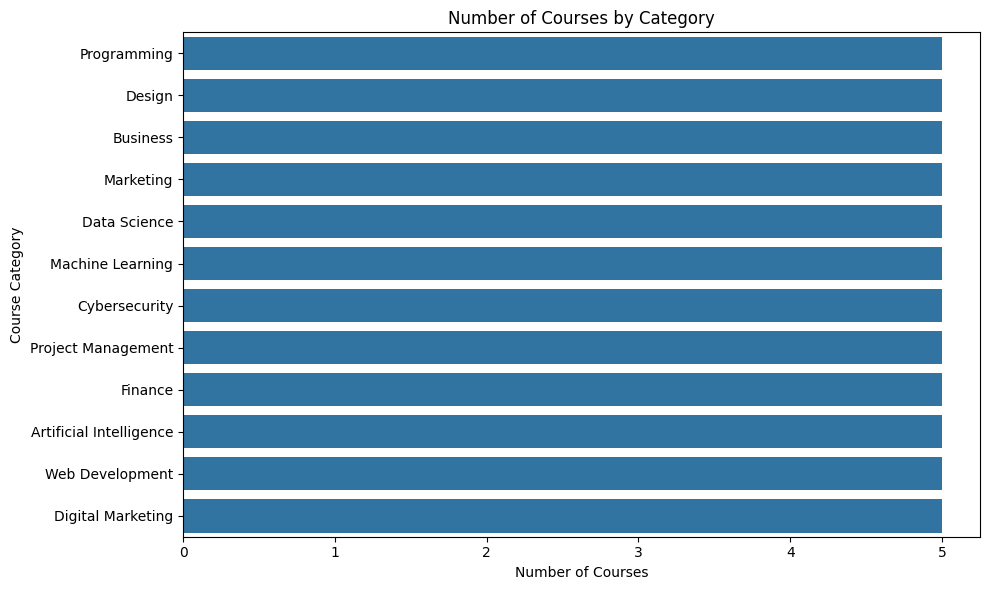

In [34]:
# Course Categories

plt.figure(figsize=(10, 6))

sns.countplot(
    data=course_data,
    y="CourseCategory",
    order=course_data["CourseCategory"].value_counts().index
)

plt.title("Number of Courses by Category")
plt.xlabel("Number of Courses")
plt.ylabel("Course Category")
plt.tight_layout()
plt.show()

# dataset mein 12 categories × 5 courses = 60 courses hain. Isliye graph completely balanced hai

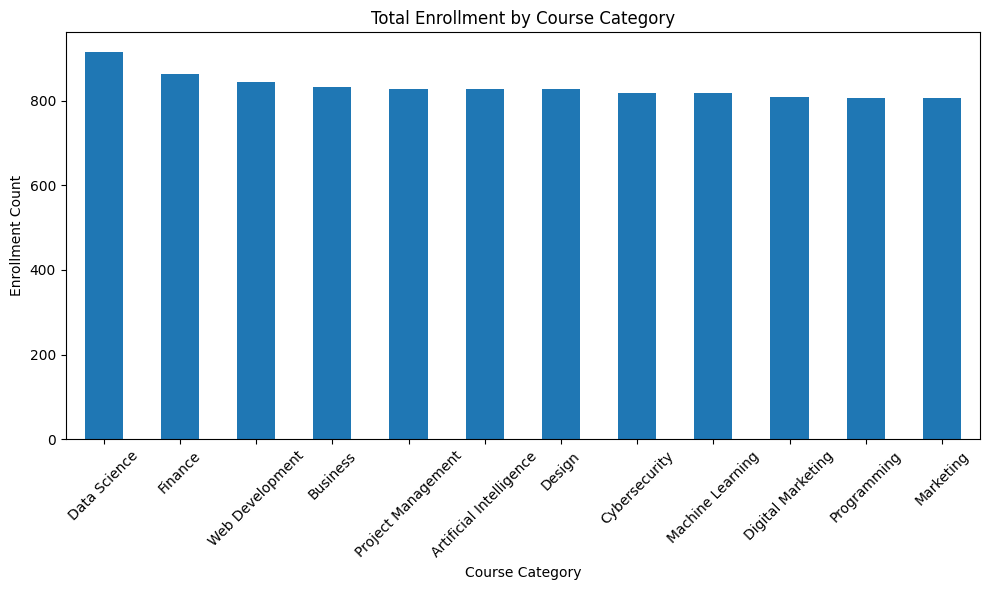

In [35]:
# Enrollment by Category

category_enrollment = (
    course_data
    .groupby("CourseCategory")["Enrollment_Count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_enrollment.plot(kind="bar")

plt.title("Total Enrollment by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Enrollment Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

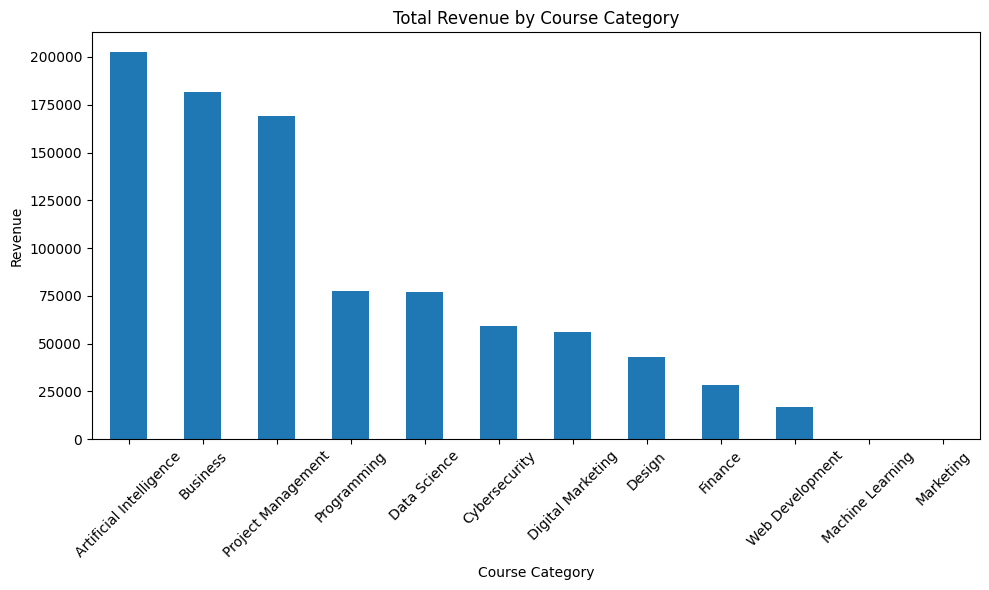

In [36]:
# Revenue by Category

category_revenue = (
    course_data
    .groupby("CourseCategory")["Course_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

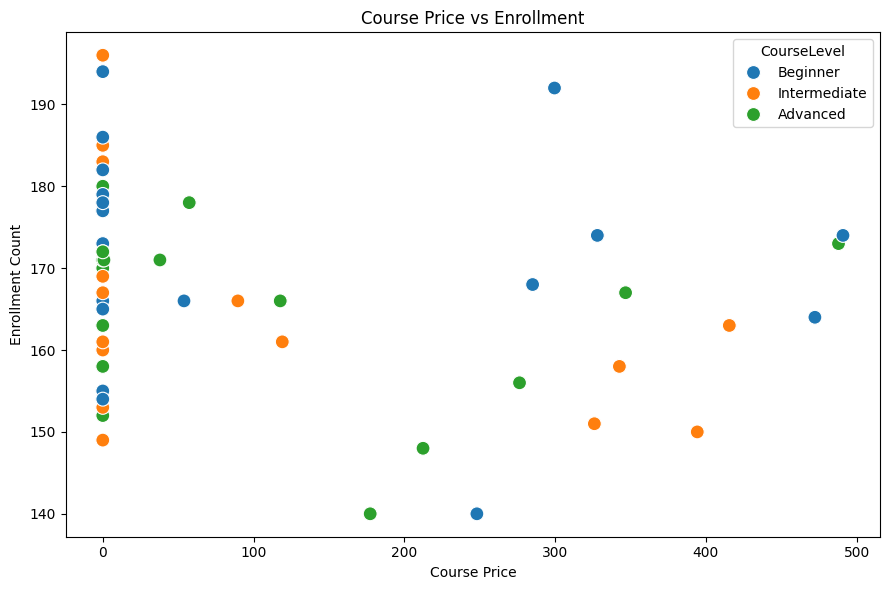

In [37]:
# Course Price vs Enrollment

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=course_data,
    x="CoursePrice",
    y="Enrollment_Count",
    hue="CourseLevel",
    s=100
)

plt.title("Course Price vs Enrollment")
plt.xlabel("Course Price")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

# ₹0 price wale courses bahut hain aur unki enrollment approximately 149–195 ke range mein hai.
# Paid courses ki prices roughly ₹50–₹500 range mein दिखाई दे रही हैं.
# Paid courses ki enrollment roughly 140–178 ke range mein hai.
# Beginner courses mein price range ke across enrollment kaafi spread hai.
# Intermediate aur Advanced courses bhi different price points par distributed hain.

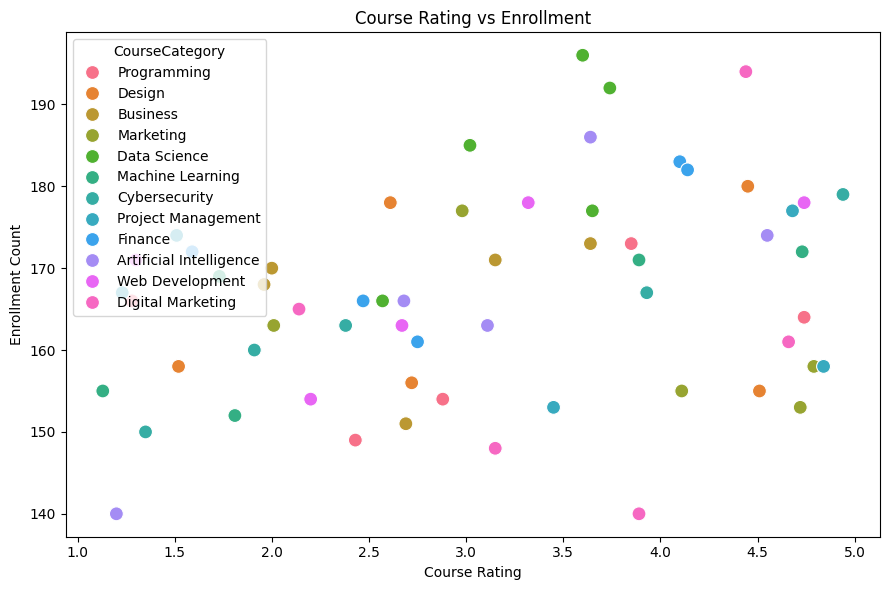

In [38]:
# Course Rating vs Enrollment

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=course_data,
    x="CourseRating",
    y="Enrollment_Count",
    hue="CourseCategory",
    s=100
)

plt.title("Course Rating vs Enrollment")
plt.xlabel("Course Rating")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

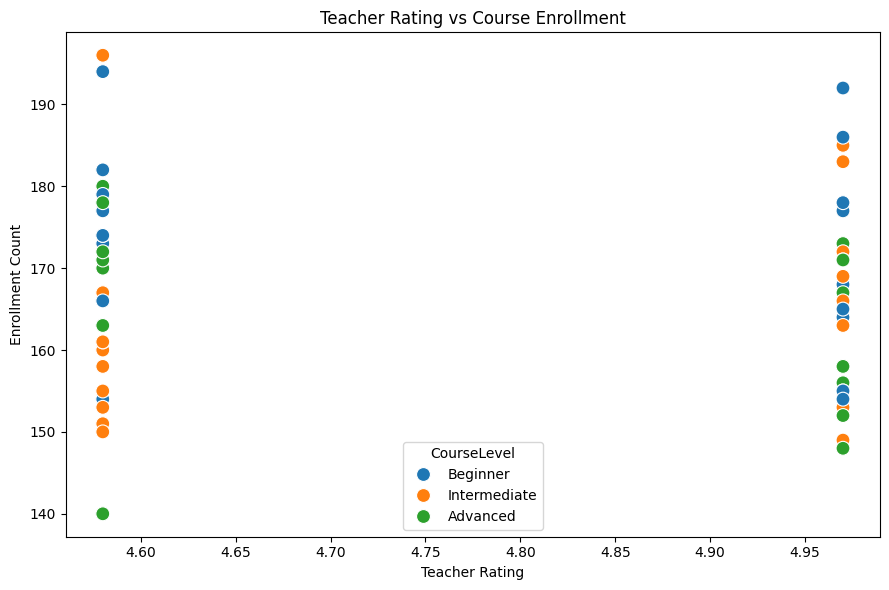

In [39]:
# Teacher Rating vs Enrollment

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=course_data,
    x="TeacherRating",
    y="Enrollment_Count",
    hue="CourseLevel",
    s=100
)

plt.title("Teacher Rating vs Course Enrollment")
plt.xlabel("Teacher Rating")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

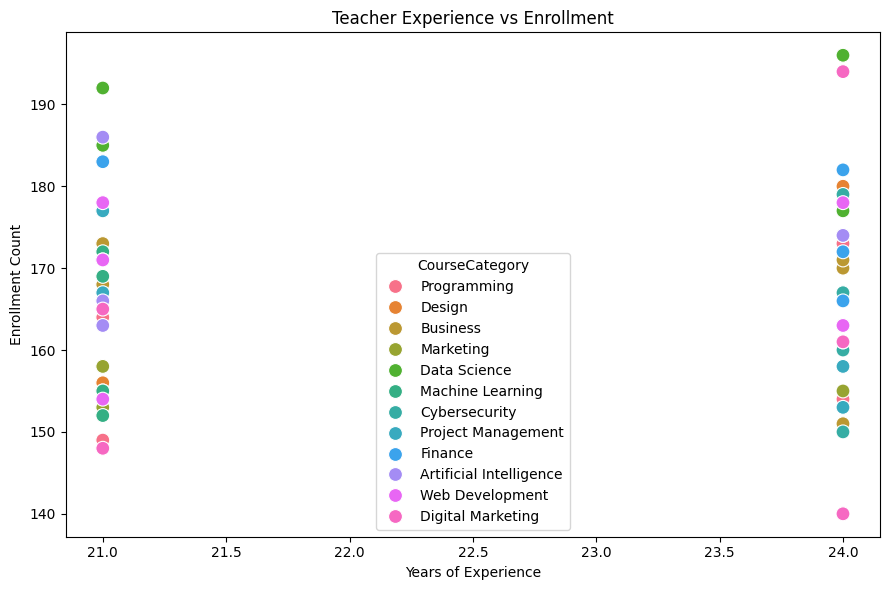

In [40]:
# Experience vs Enrollment

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=course_data,
    x="YearsOfExperience",
    y="Enrollment_Count",
    hue="CourseCategory",
    s=100
)

plt.title("Teacher Experience vs Enrollment")
plt.xlabel("Years of Experience")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

# Teacher experience sirf 21 aur 24 years ke around dikh rha h
# 21 years experience wale teachers ke enrollments approximately 148–192 ke range mein hain.
# 24 years experience wale teachers ke enrollments approximately 140–194 ke range mein hain.
# Same experience level par enrollment kaafi different hai.
# Isliye experience alone se enrollment ko explain karna straightforward nahi lagta.

In [41]:
# Course Level Analysis

level_analysis = (
    course_data
    .groupby("CourseLevel", observed=False)
    .agg(
        Courses=("CourseID", "count"),
        Enrollment=("Enrollment_Count", "sum"),
        Revenue=("Course_Revenue", "sum"),
        Average_Rating=("CourseRating", "mean"),
        Average_Price=("CoursePrice", "mean")
    )
    .sort_values("Enrollment", ascending=False)
)

display(level_analysis)

,Courses,Enrollment,Revenue,Average_Rating,Average_Price
CourseLevel,,,,,
Beginner,21,3573,369021.38,3.189048,103.702381
Advanced,21,3475,278036.18,2.813810,81.638095
Intermediate,18,2952,264265.91,3.322778,93.723889


In [42]:
# Price Band Analysis

price_analysis = (
    course_data
    .groupby("Price_Band", observed=False)
    .agg(
        Courses=("CourseID", "count"),
        Enrollment=("Enrollment_Count", "sum"),
        Revenue=("Course_Revenue", "sum"),
        Average_Course_Rating=("CourseRating", "mean")
    )
)

display(price_analysis)

,Courses,Enrollment,Revenue,Average_Course_Rating
Price_Band,,,,
Free,38,6403,0.00,3.188158
Low,13,2123,318843.43,2.850769
Medium,9,1474,592480.04,3.073333
High,0,0,0.00,NaN


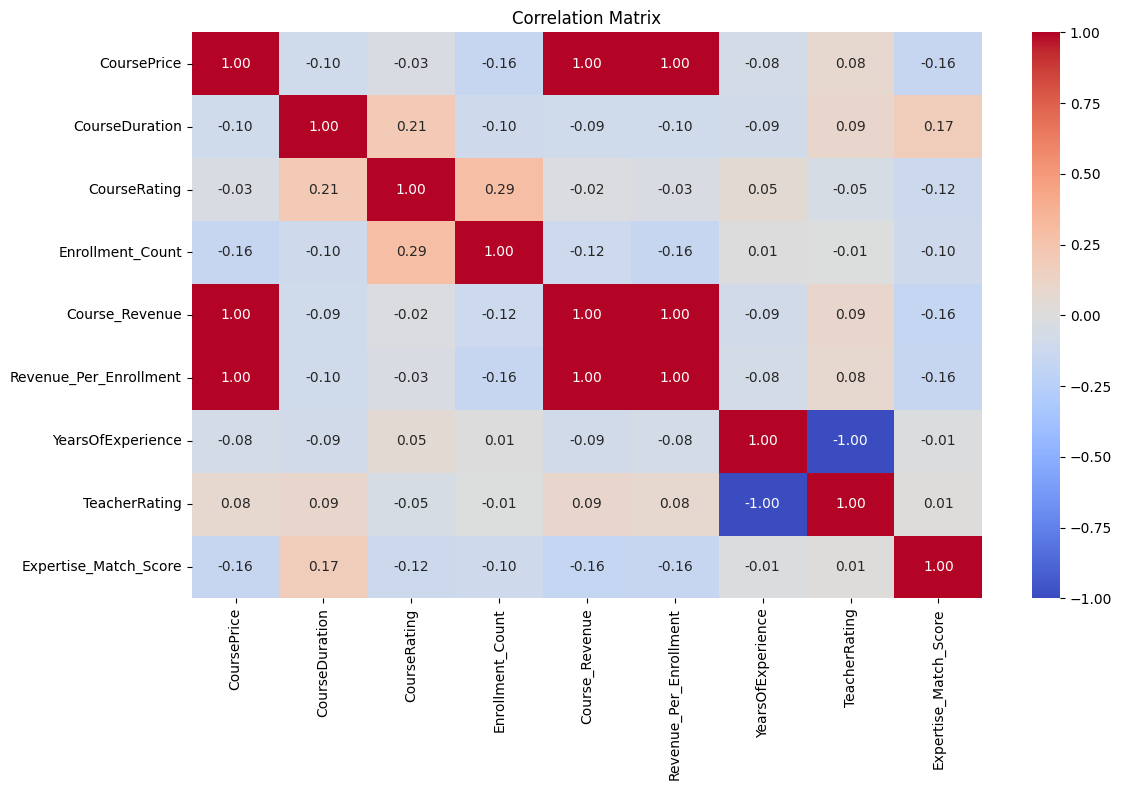

In [43]:
# Correlation Matrix

numeric_cols = [
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "Enrollment_Count",
    "Course_Revenue",
    "Revenue_Per_Enrollment",
    "YearsOfExperience",
    "TeacherRating",
    "Expertise_Match_Score"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    course_data[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [44]:
# Top Courses

top_enrollment_courses = (
    course_data
    .sort_values("Enrollment_Count", ascending=False)
    [
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CourseLevel",
            "Enrollment_Count",
            "Course_Revenue"
        ]
    ]
    .head(10)
)

display(top_enrollment_courses)

,CourseID,CourseName,CourseCategory,CourseLevel,Enrollment_Count,Course_Revenue
20,CR00021,Data Analysis with Python,Data Science,Intermediate,196,0.00
57,CR00058,Social Media Strategy,Digital Marketing,Beginner,194,0.00
24,CR00025,Statistical Analysis,Data Science,Beginner,192,57517.44
47,CR00048,AI Ethics,Artificial Intelligence,Beginner,186,0.00
22,CR00023,Machine Learning Fundamentals,Data Science,Intermediate,185,0.00
41,CR00042,Investment Strategies,Finance,Intermediate,183,0.00
42,CR00043,Corporate Finance,Finance,Beginner,182,0.00
9,CR00010,3D Modeling,Design,Advanced,180,0.00
34,CR00035,Cyber Threat Intelligence,Cybersecurity,Beginner,179,0.00
6,CR00007,UI/UX Design,Design,Advanced,178,0.00


In [45]:
top_revenue_courses = (
    course_data
    .sort_values("Course_Revenue", ascending=False)
    [
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CourseLevel",
            "Enrollment_Count",
            "Course_Revenue"
        ]
    ]
    .head(10)
)

display(top_revenue_courses)

,CourseID,CourseName,CourseCategory,CourseLevel,Enrollment_Count,Course_Revenue
49,CR00050,Computer Vision,Artificial Intelligence,Beginner,174,85416.60
11,CR00012,Business Strategy,Business,Advanced,173,84410.16
0,CR00001,Python Basics,Programming,Beginner,164,77453.92
48,CR00049,Deep Learning,Artificial Intelligence,Intermediate,163,67728.13
33,CR00034,Data Encryption,Cybersecurity,Intermediate,150,59139.00
38,CR00039,Project Planning,Project Management,Advanced,167,57900.57
24,CR00025,Statistical Analysis,Data Science,Beginner,192,57517.44
39,CR00040,Leadership in Projects,Project Management,Beginner,174,57070.26
37,CR00038,Risk Management,Project Management,Intermediate,158,54132.38
10,CR00011,Entrepreneurship 101,Business,Intermediate,151,49229.02


# Modelling Dataset:

In [46]:
# We will predict two targets separately:
# Model 1 Enrollment_Count
# Model 2 Course_Revenue
# We must not use the target itself as an input featur

In [47]:
model_data = course_data.copy()

# Remove columns that should not be directly used as predictors
drop_cols = [
    "CourseID",
    "CourseName",
    "TeacherID",
    "Enrollment_Count",
    "Course_Revenue",
    "Unique_Learners",
    "Transaction_Count",
    "Average_Transaction_Amount",
    "Revenue_Per_Enrollment"
]

# Keep target columns separately
y_enrollment = model_data["Enrollment_Count"]
y_revenue = model_data["Course_Revenue"]

X = model_data.drop(columns=drop_cols)

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)

Feature columns:
['CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'Paid_Enrollment_Count', 'Free_Enrollment_Count', 'Paid_Enrollment_Rate', 'Expertise', 'YearsOfExperience', 'TeacherRating', 'Price_Band', 'Duration_Bucket', 'Rating_Tier', 'Experience_Bucket', 'Expertise_Match_Score']

Feature shape: (60, 17)


In [48]:
# Handle missing values:

# Fill categorical missing values
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_columns:
    X[col] = X[col].astype("object").fillna("Unknown")

# Fill numerical missing values
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

print("Missing values after preprocessing:")
print(X.isnull().sum())

Missing values after preprocessing:
CourseCategory           0
CourseType               0
CourseLevel              0
CoursePrice              0
CourseDuration           0
CourseRating             0
Paid_Enrollment_Count    0
Free_Enrollment_Count    0
Paid_Enrollment_Rate     0
Expertise                0
YearsOfExperience        0
TeacherRating            0
Price_Band               0
Duration_Bucket          0
Rating_Tier              0
Experience_Bucket        0
Expertise_Match_Score    0
dtype: int64


In [49]:
# Identify Feature Types

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['CourseCategory', 'CourseType', 'CourseLevel', 'Expertise', 'Price_Band', 'Duration_Bucket', 'Rating_Tier', 'Experience_Bucket']

Numerical features:
['CoursePrice', 'CourseDuration', 'CourseRating', 'Paid_Enrollment_Count', 'Free_Enrollment_Count', 'Paid_Enrollment_Rate', 'YearsOfExperience', 'TeacherRating', 'Expertise_Match_Score']


In [50]:
# Train/Test Split

X_train, X_test, y_enroll_train, y_enroll_test = train_test_split(
    X,
    y_enrollment,
    test_size=0.20,
    random_state=42
)

_, _, y_revenue_train, y_revenue_test = train_test_split(
    X,
    y_revenue,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape)
print("Testing rows:", X_test.shape)

Training rows: (48, 17)
Testing rows: (12, 17)


In [51]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [52]:
# Define Models

# Humhara EduPro project course enrollment/demand predict kar raha hai.
# Regression use ho raha hai kyunki Enrollment_Count ek numerical value hai, jaise 150, 170, 190 etc.

models = {
    "Linear Regression": LinearRegression(),  # Ye features aur enrollment ke beech ek linear relationship fit karne ki koshish karta hai. Data points ke through ek best-fitting line find karna

    "Ridge Regression": Ridge(  # Ridge, Linear Regression ka regularized version hai. alpha=1.0 regularization ki strength control karta hai
                                # Agar features ek-dusre ke saath highly correlated hain, Ridge coefficients ko control karne mein help kar sakta hai
                                # Tumhari correlation matrix mein kuch very high correlations hain, isliye Ridge test karna relevant hai
        alpha=1.0
    ),

    "Lasso Regression": Lasso(  # Lasso bhi regularization use karta hai. Iska ek useful property hai: Ye kuch feature coefficients ko exactly 0 kar sakta hai
                                # Isliye Lasso ko feature selection ke liye bhi use kiya ja sakta hai. alpha=0.01 Regularization strength
        alpha=0.01,  # alpha=0.01 = relatively small regularization value hai
        max_iter=10000  # Model ko maximum 10,000 iterations tak optimize karne allow karta hai. Ye convergence problems avoid karne mein help kar sakta hai
    ),

    "Random Forest": RandomForestRegressor(  # Random Forest bahut saare Decision Trees banata hai aur unke predictions ko combine karta hai
        n_estimators=300, # 300 decision trees create honge
        max_depth=None, # Tree ki maximum depth explicitly restrict nahi ki gayi
        min_samples_split=2, # A node ko split karne ke liye minimum 2 samples required hain
        random_state=42,
        n_jobs=-1 # Available CPU cores ko parallel processing ke liye use karta hai
    ),

    "Gradient Boosting": GradientBoostingRegressor(  # Gradient Boosting bhi tree-based model hai, but Random Forest se iska approach different hai
                                                     # Random Forest mein trees generally parallel/independent fashion mein build hote hain
                                                     # Gradient Boosting mein: Har next tree previous model ki errors ko improve karne ki koshish karta hai
        n_estimators=200,  # 200 boosting stages/trees
        learning_rate=0.05,  # Har new tree ka contribution control karta hai. Lower learning rate → learning slower but potentially more controlled.
        max_depth=3,  # Har tree ki maximum depth 3 rakhi gayi hai
        random_state=42
    )
}

# dictionary use kiya hai. models = { ... } Isse saare models ek hi dictionary mein store ho gaye:
print("Models created:")
print(list(models.keys()))

Models created:
['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'Gradient Boosting']


In [53]:
# Evaluation Function

def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    return model, predictions, mae, rmse, r2

In [54]:
# Enrollment Prediction Models

enrollment_results = []

enrollment_models = {}

for model_name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    fitted_model, predictions, mae, rmse, r2 = evaluate_model(
        pipeline,
        X_train,
        X_test,
        y_enroll_train,
        y_enroll_test
    )
    
    enrollment_models[model_name] = fitted_model
    
    enrollment_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

enrollment_results_df = pd.DataFrame(
    enrollment_results
).sort_values(
    "R2",
    ascending=False
)

display(enrollment_results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,7.105427e-14,8.760159e-14,1.000000
2,Lasso Regression,1.413774e-01,1.796384e-01,0.999823
4,Gradient Boosting,1.836983e+00,2.787250e+00,0.957367
3,Random Forest,3.170000e+00,4.685414e+00,0.879526
1,Ridge Regression,9.777763e+00,1.270432e+01,0.114270


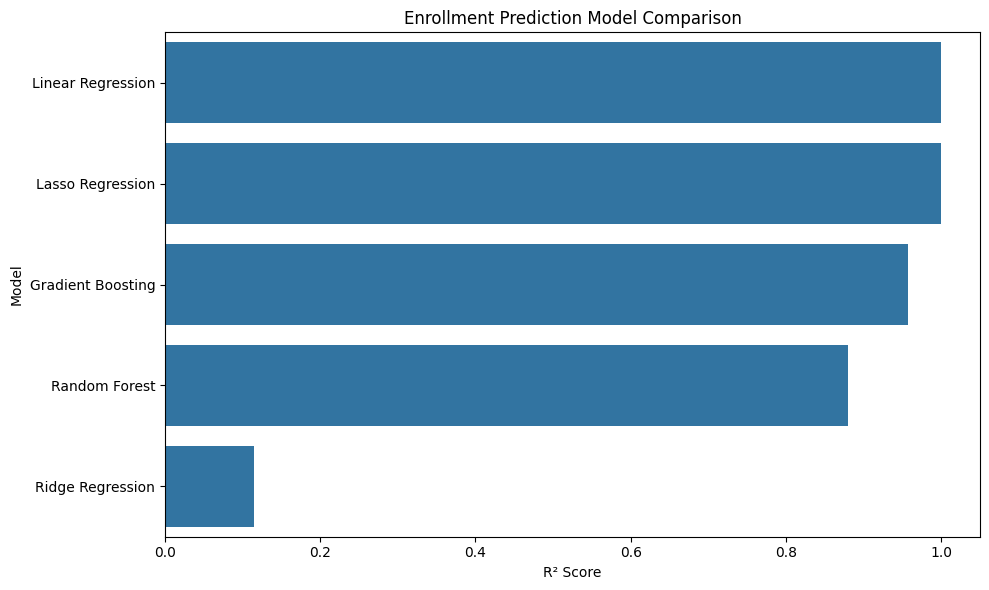

In [55]:
# Enrollment Model Comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=enrollment_results_df,
    x="R2",
    y="Model"
)

plt.title("Enrollment Prediction Model Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [56]:
# Best Enrollment Model

best_enrollment_model_name = (
    enrollment_results_df
    .iloc[0]["Model"]
)

best_enrollment_model = (
    enrollment_models[best_enrollment_model_name]
)

print(
    "Best Enrollment Model:",
    best_enrollment_model_name
)

Best Enrollment Model: Linear Regression


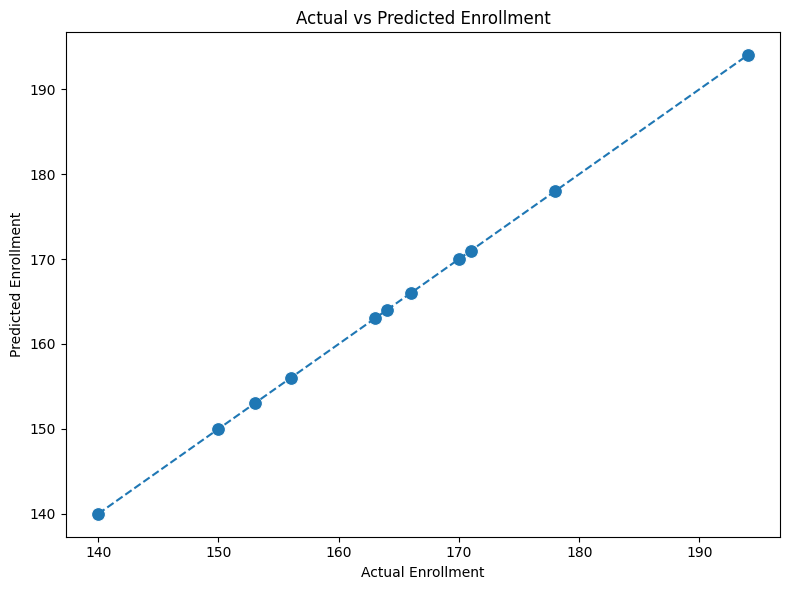

In [57]:
# Actual vs Predicted Enrollment

enrollment_predictions = best_enrollment_model.predict(
    X_test
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_enroll_test,
    y=enrollment_predictions,
    s=100
)

plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted Enrollment")

# Perfect prediction line
min_val = min(
    y_enroll_test.min(),
    enrollment_predictions.min()
)

max_val = max(
    y_enroll_test.max(),
    enrollment_predictions.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [58]:
# Revenue Prediction Models

revenue_results = []

revenue_models = {}

for model_name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    fitted_model, predictions, mae, rmse, r2 = evaluate_model(
        pipeline,
        X_train,
        X_test,
        y_revenue_train,
        y_revenue_test
    )
    
    revenue_models[model_name] = fitted_model
    
    revenue_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

revenue_results_df = pd.DataFrame(
    revenue_results
).sort_values(
    "R2",
    ascending=False
)

display(revenue_results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,1382.095976,1650.741611,0.996489
2,Lasso Regression,1478.420745,1746.532536,0.996070
1,Ridge Regression,2169.169768,2905.583626,0.989123
4,Gradient Boosting,2998.940532,4555.933469,0.973258
3,Random Forest,3291.266153,4627.631468,0.972410


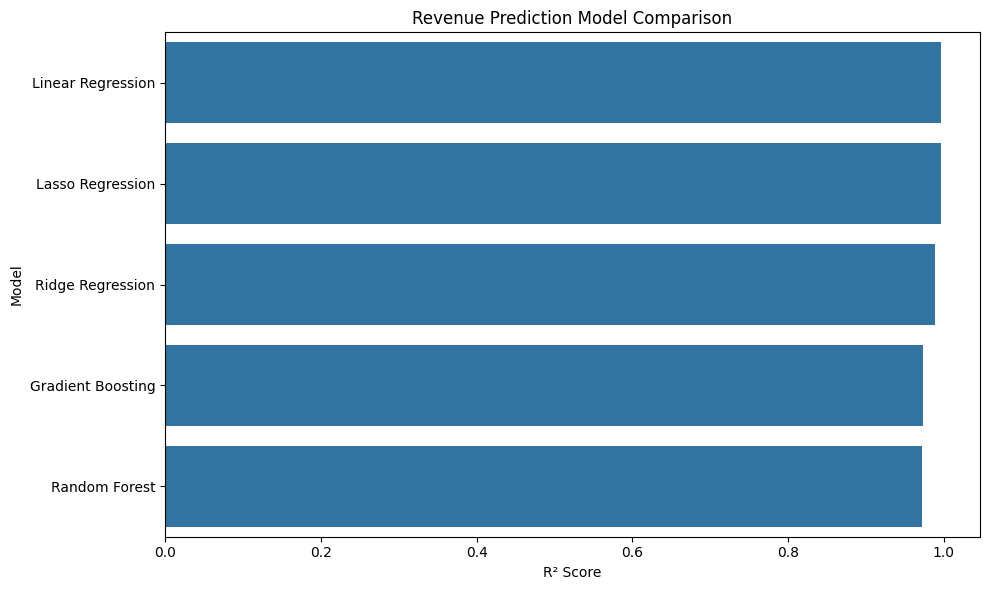

In [59]:
# Revenue Model Comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_results_df,
    x="R2",
    y="Model"
)

plt.title("Revenue Prediction Model Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [60]:
# Best Revenue Model

best_revenue_model_name = (
    revenue_results_df
    .iloc[0]["Model"]
)

best_revenue_model = (
    revenue_models[best_revenue_model_name]
)

print(
    "Best Revenue Model:",
    best_revenue_model_name
)

Best Revenue Model: Linear Regression


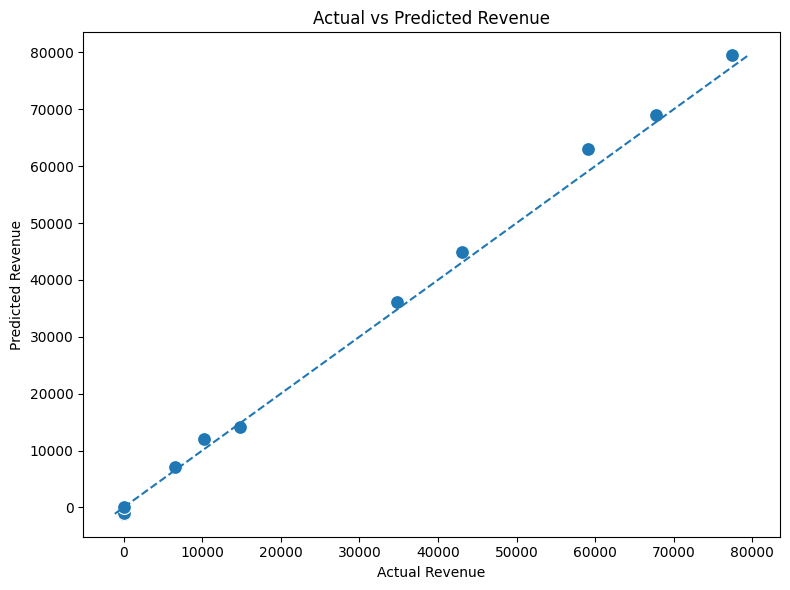

In [61]:
# Actual vs Predicted Revenue

revenue_predictions = best_revenue_model.predict(
    X_test
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_revenue_test,
    y=revenue_predictions,
    s=100
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

min_val = min(
    y_revenue_test.min(),
    revenue_predictions.min()
)

max_val = max(
    y_revenue_test.max(),
    revenue_predictions.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [62]:
# Feature Importance (For tree-based models, we can inspect feature importance after preprocessing)

# Select Random Forest enrollment pipeline
rf_enrollment = enrollment_models["Random Forest"]

# Extract preprocessing component
enrollment_preprocessor = (
    rf_enrollment.named_steps["preprocessor"]
)

# Get feature names
feature_names = (
    enrollment_preprocessor
    .get_feature_names_out()
)

# Get Random Forest
rf_model = (
    rf_enrollment.named_steps["model"]
)

importance_values = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance_df.head(20)
)

,Feature,Importance
0,num__CoursePrice,0.880297
30,cat__Price_Band_Medium,0.059244
3,num__Paid_Enrollment_Count,0.026114
2,num__CourseRating,0.004292
1,num__CourseDuration,0.004190
21,cat__CourseType_Free,0.003759
9,cat__CourseCategory_Artificial Intelligence,0.002299
14,cat__CourseCategory_Digital Marketing,0.002186
29,cat__Price_Band_Low,0.002010
32,cat__Duration_Bucket_Medium,0.001770


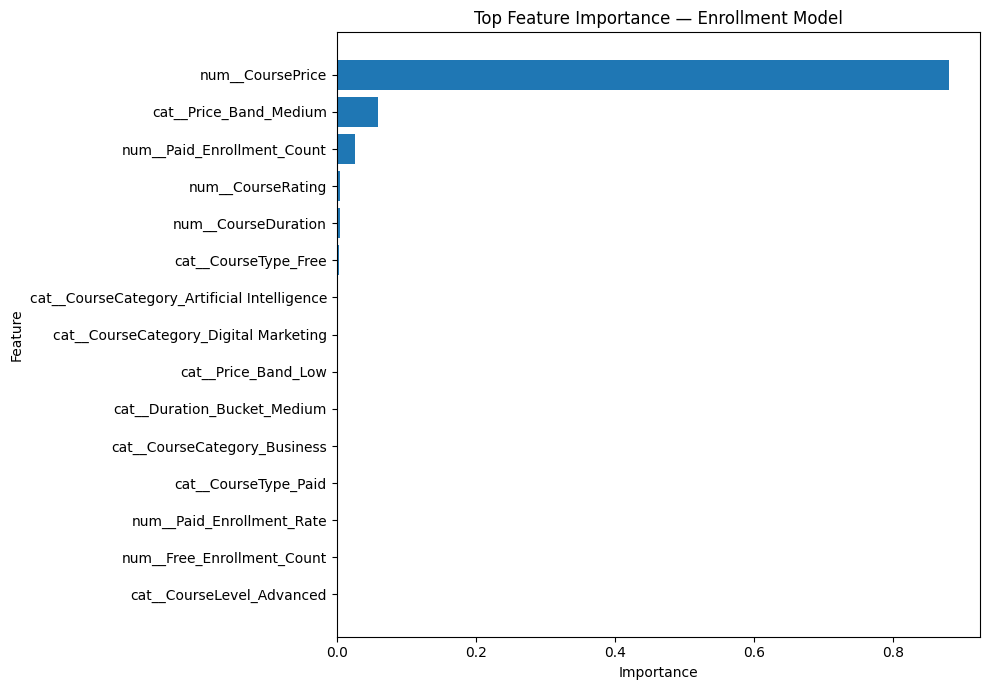

In [63]:
# Plot Feature Importance

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Feature Importance — Enrollment Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [64]:
# Revenue Feature Importance

rf_revenue = revenue_models["Random Forest"]

revenue_preprocessor = (
    rf_revenue.named_steps["preprocessor"]
)

revenue_feature_names = (
    revenue_preprocessor
    .get_feature_names_out()
)

rf_revenue_model = (
    rf_revenue.named_steps["model"]
)

revenue_importance_df = pd.DataFrame({
    "Feature": revenue_feature_names,
    "Importance": rf_revenue_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    revenue_importance_df.head(20)
)

,Feature,Importance
0,num__CoursePrice,0.880297
30,cat__Price_Band_Medium,0.059244
3,num__Paid_Enrollment_Count,0.026114
2,num__CourseRating,0.004292
1,num__CourseDuration,0.004190
21,cat__CourseType_Free,0.003759
9,cat__CourseCategory_Artificial Intelligence,0.002299
14,cat__CourseCategory_Digital Marketing,0.002186
29,cat__Price_Band_Low,0.002010
32,cat__Duration_Bucket_Medium,0.001770


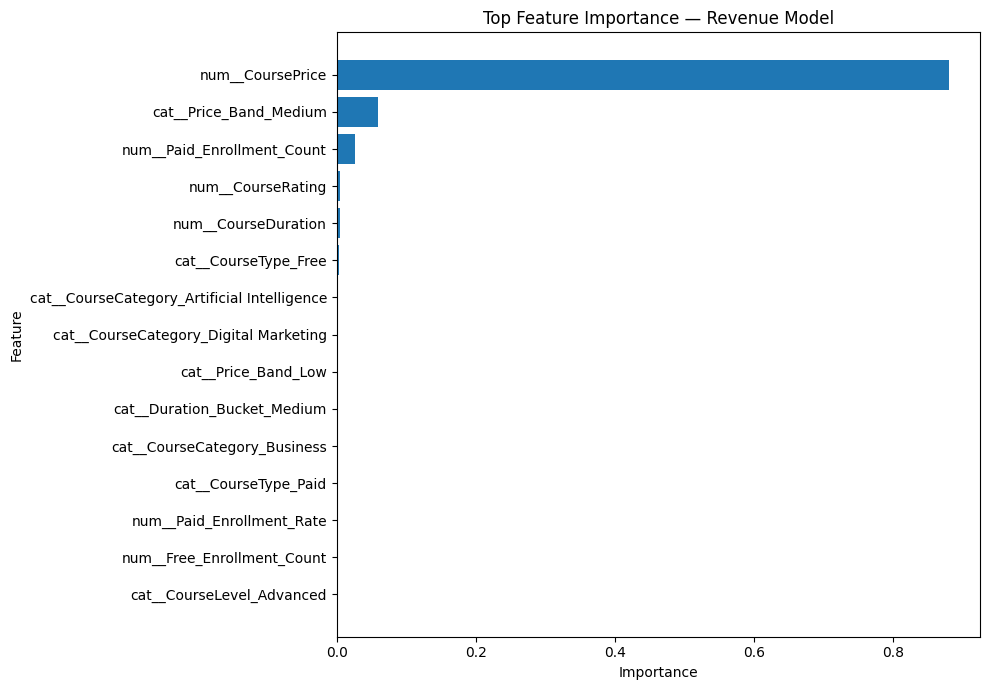

In [65]:
# Plot Revenue Feature Importance

top_revenue_features = (
    revenue_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_revenue_features["Feature"],
    top_revenue_features["Importance"]
)

plt.title("Top Feature Importance — Revenue Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [66]:
# Category-Level Revenue

category_summary = (
    course_data
    .groupby("CourseCategory")
    .agg(
        Total_Courses=("CourseID", "count"),
        Total_Enrollments=("Enrollment_Count", "sum"),
        Total_Revenue=("Course_Revenue", "sum"),
        Average_Price=("CoursePrice", "mean"),
        Average_Course_Rating=("CourseRating", "mean"),
        Average_Teacher_Rating=("TeacherRating", "mean")
    )
    .reset_index()
)

category_summary["Revenue_Per_Enrollment"] = np.where(
    category_summary["Total_Enrollments"] > 0,
    category_summary["Total_Revenue"] /
    category_summary["Total_Enrollments"],
    0
)

display(category_summary)

,CourseCategory,Total_Courses,Total_Enrollments,Total_Revenue,Average_Price,Average_Course_Rating,Average_Teacher_Rating,Revenue_Per_Enrollment
0,Artificial Intelligence,5,829,202750.67,248.820,3.036,4.814,244.572581
1,Business,5,833,181527.58,219.798,2.688,4.736,217.920264
2,Cybersecurity,5,819,59139.00,78.852,2.902,4.580,72.208791
3,Data Science,5,916,77052.32,83.450,3.316,4.814,84.118253
4,Design,5,827,43113.72,55.274,3.162,4.814,52.132672
5,Digital Marketing,5,808,56261.32,77.946,3.656,4.736,69.630347
6,Finance,5,864,28106.20,34.580,3.010,4.658,32.530324
7,Machine Learning,5,819,133.38,0.156,2.658,4.970,0.162857
8,Marketing,5,806,0.00,0.000,3.722,4.814,0.000000
9,Programming,5,806,77453.92,94.456,3.036,4.736,96.096675


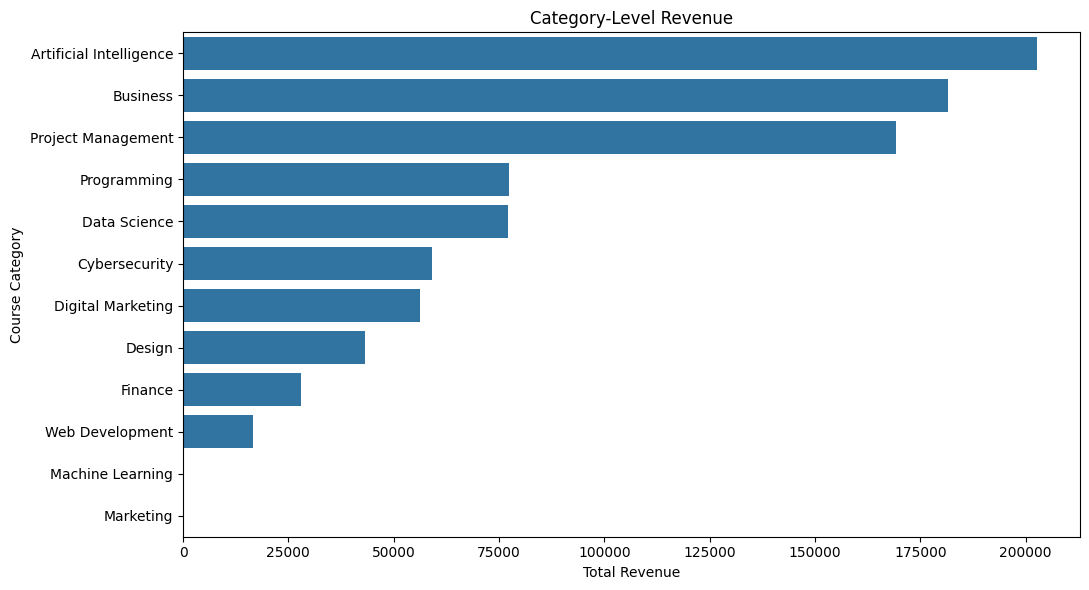

In [67]:
# Category Revenue Visualization

plt.figure(figsize=(11, 6))

sns.barplot(
    data=category_summary.sort_values(
        "Total_Revenue",
        ascending=False
    ),
    x="Total_Revenue",
    y="CourseCategory"
)

plt.title("Category-Level Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Course Category")

plt.tight_layout()
plt.show()

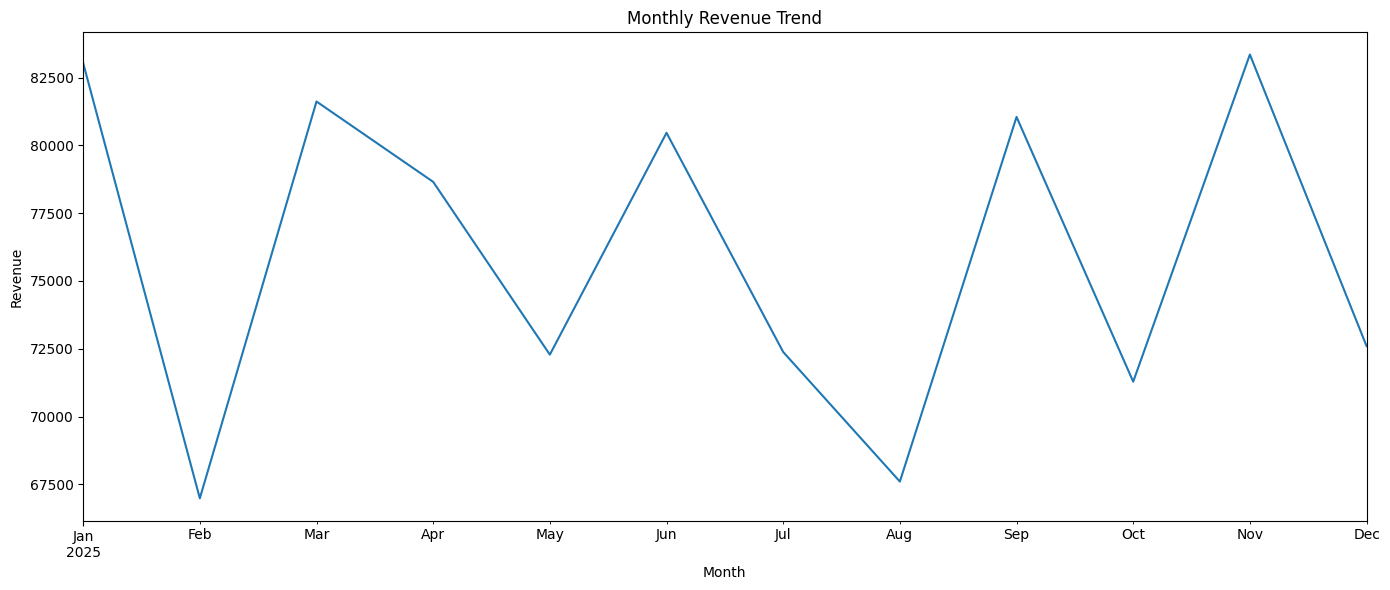

In [68]:
# Monthly Revenue Trend

monthly_revenue_plot = (
    transactions_clean
    .groupby(
        transactions_clean["TransactionDate"].dt.to_period("M")
    )["Amount"]
    .sum()
)

plt.figure(figsize=(14, 6))

monthly_revenue_plot.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [69]:
# Transaction Analysis

payment_analysis = (
    transactions_clean
    .groupby("PaymentMethod")
    .agg(
        Transactions=("TransactionID", "count"),
        Revenue=("Amount", "sum"),
        Average_Amount=("Amount", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

display(payment_analysis)

,Transactions,Revenue,Average_Amount
PaymentMethod,,,
PayPal,3389,305580.74,90.168410
Bank Transfer,3278,305052.21,93.060467
Credit Card,3333,300690.52,90.216178


In [70]:
# Course Performance Score  (For the dashboard, it is useful to have a simple descriptive performance indicator)
# Normalize components for descriptive scoring
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "Enrollment_Count",
    "Course_Revenue",
    "CourseRating",
    "TeacherRating"
]

scaler = MinMaxScaler()

scaled_scores = scaler.fit_transform(
    course_data[score_columns]
)

scaled_score_df = pd.DataFrame(
    scaled_scores,
    columns=[
        "Enrollment_Score",
        "Revenue_Score",
        "Course_Rating_Score",
        "Teacher_Rating_Score"
    ],
    index=course_data.index
)

course_data = pd.concat(
    [course_data, scaled_score_df],
    axis=1
)

course_data["Course_Performance_Score"] = (
    0.35 * course_data["Enrollment_Score"]
    +
    0.35 * course_data["Revenue_Score"]
    +
    0.15 * course_data["Course_Rating_Score"]
    +
    0.15 * course_data["Teacher_Rating_Score"]
) * 100

display(
    course_data[
        [
            "CourseName",
            "Enrollment_Count",
            "Course_Revenue",
            "Course_Performance_Score"
        ]
    ]
    .sort_values(
        "Course_Performance_Score",
        ascending=False
    )
    .head(10)
)

# This score is a descriptive portfolio KPI, not a machine-learning target.

,CourseName,Enrollment_Count,Course_Revenue,Course_Performance_Score
24,Statistical Analysis,192,57517.44,81.343731
11,Business Strategy,173,84410.16,80.094495
0,Python Basics,164,77453.92,75.949839
49,Computer Vision,174,85416.60,69.714567
48,Deep Learning,163,67728.13,64.922311
38,Project Planning,167,57900.57,55.993831
14,Leadership Essentials,168,47888.40,55.390296
47,AI Ethics,186,0.00,53.631890
41,Investment Strategies,183,0.00,53.567913
35,Agile Project Management,177,0.00,52.101378


In [71]:
# Sample Prediction Function  (This function will later be useful in Streamlit)
def predict_course_demand(
    course_price,
    course_duration,
    course_rating,
    course_category,
    course_type,
    course_level,
    years_experience,
    teacher_rating,
    expertise
):
    
    input_data = pd.DataFrame({
        "CourseCategory": [course_category],
        "CourseType": [course_type],
        "CourseLevel": [course_level],
        "CoursePrice": [course_price],
        "CourseDuration": [course_duration],
        "CourseRating": [course_rating],
        "Expertise": [expertise],
        "YearsOfExperience": [years_experience],
        "TeacherRating": [teacher_rating],
        "Price_Band": [
            pd.cut(
                [course_price],
                bins=[-1, 0, 300, 700, np.inf],
                labels=["Free", "Low", "Medium", "High"]
            )[0]
        ],
        "Duration_Bucket": [
            pd.cut(
                [course_duration],
                bins=[-np.inf, 10, 25, 50, np.inf],
                labels=[
                    "Short",
                    "Medium",
                    "Long",
                    "Very Long"
                ]
            )[0]
        ],
        "Rating_Tier": [
            pd.cut(
                [course_rating],
                bins=[0, 2.5, 3.5, 4.25, 5],
                labels=[
                    "Low",
                    "Average",
                    "Good",
                    "Excellent"
                ],
                include_lowest=True
            )[0]
        ],
        "Experience_Bucket": [
            pd.cut(
                [years_experience],
                bins=[-1, 2, 5, 10, np.inf],
                labels=[
                    "Beginner",
                    "Intermediate",
                    "Experienced",
                    "Highly Experienced"
                ]
            )[0]
        ],
        "Expertise_Match_Score": [
            int(
                str(course_category).lower()
                ==
                str(expertise).lower()
            )
        ]
    })
    
    enrollment_prediction = best_enrollment_model.predict(
        input_data
    )[0]
    
    revenue_prediction = best_revenue_model.predict(
        input_data
    )[0]
    
    return enrollment_prediction, revenue_prediction

In [72]:
# Test Prediction

predicted_enrollment, predicted_revenue = predict_course_demand(
    course_price=499,
    course_duration=20,
    course_rating=4.5,
    course_category=course_data["CourseCategory"].iloc[0],
    course_type=course_data["CourseType"].iloc[0],
    course_level=course_data["CourseLevel"].iloc[0],
    years_experience=8,
    teacher_rating=4.3,
    expertise=course_data["Expertise"].iloc[0]
)

print(
    "Predicted Enrollment:",
    round(predicted_enrollment, 2)
)

print(
    "Predicted Revenue:",
    round(predicted_revenue, 2)
)

# best_enrollment_model ko training ke time 3 extra columns mile the: Free_Enrollment_Count Paid_Enrollment_Count Paid_Enrollment_Rate
# Lekin predict_course_demand() ke andar jo input_data ban raha hai, usme ye columns nahi hain. Isliye pipeline bol rahi hai: ValueError: columns are missing:
# so target leakage ka risk hai.

ValueError: columns are missing: {'Free_Enrollment_Count', 'Paid_Enrollment_Rate', 'Paid_Enrollment_Count'}

In [73]:
# Humein model ko sirf genuinely available course features par retrain karna chahiye
# Isliye pehle check karo ki model training mein exactly kya features use hue

print("Enrollment model features:")
print(best_enrollment_model.named_steps["preprocessor"].feature_names_in_)

# best_enrollment_model mein total 18 features train kiye gaye the Lekin prediction function sirf kuch original inputs de raha tha. Isliye preprocessing 
# step missing columns par error de raha tha.

Enrollment model features:
['CourseCategory' 'CourseType' 'CourseLevel' 'CoursePrice'
 'CourseDuration' 'CourseRating' 'Paid_Enrollment_Count'
 'Free_Enrollment_Count' 'Paid_Enrollment_Rate' 'Expertise'
 'YearsOfExperience' 'TeacherRating' 'Price_Band' 'Duration_Bucket'
 'Rating_Tier' 'Experience_Bucket' 'Expertise_Match_Score']


In [74]:
# Humein model dobara train karna chahiye clean predictive feature set ye rakho:

features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "Expertise",
    "YearsOfExperience",
    "TeacherRating"
]

target = "Enrollment_Count"

X = course_data[features].copy()
y = course_data["Enrollment_Count"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

X shape: (60, 9)
y shape: (60,)

Features used:
['CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'Expertise', 'YearsOfExperience', 'TeacherRating']


In [75]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (48, 9)
X_test: (12, 9)


In [76]:
# Define columns
numeric_features = [
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "YearsOfExperience",
    "TeacherRating"
]

categorical_features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "Expertise"
]

In [77]:
# Preprocessing (For Linear Regression, Ridge and Lasso, scaling numerical variables is useful)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [78]:
# Retrain your models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=0.01,
        max_iter=10000
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [79]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("All models trained successfully.")

All models trained successfully.


In [80]:
# Check model features

best_enrollment_model = trained_models["Linear Regression"]

print(
    best_enrollment_model
    .named_steps["preprocessor"]
    .feature_names_in_
)

['CourseCategory' 'CourseType' 'CourseLevel' 'CoursePrice'
 'CourseDuration' 'CourseRating' 'Expertise' 'YearsOfExperience'
 'TeacherRating']


In [81]:
# Evaluate again
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R2
3,Random Forest,11.503889,13.874710,-0.056444
1,Ridge Regression,9.907756,13.875772,-0.056606
4,Gradient Boosting,12.568889,15.007271,-0.235953
2,Lasso Regression,10.891430,15.347545,-0.292637
0,Linear Regression,11.151174,15.552547,-0.327400


In [82]:
# Prediction function
# Once the corrected model is trained:

best_enrollment_model = trained_models["Linear Regression"]
def predict_course_demand(
    course_price,
    course_duration,
    course_rating,
    course_category,
    course_type,
    course_level,
    years_experience,
    teacher_rating,
    expertise
):

    input_data = pd.DataFrame({
        "CourseCategory": [course_category],
        "CourseType": [course_type],
        "CourseLevel": [course_level],
        "CoursePrice": [course_price],
        "CourseDuration": [course_duration],
        "CourseRating": [course_rating],
        "Expertise": [expertise],
        "YearsOfExperience": [years_experience],
        "TeacherRating": [teacher_rating]
    })

    enrollment_prediction = best_enrollment_model.predict(
        input_data
    )[0]

    enrollment_prediction = max(
        0,
        enrollment_prediction
    )

    revenue_prediction = (
        enrollment_prediction * course_price
    )

    return enrollment_prediction, revenue_prediction

In [83]:
# test:

predicted_enrollment, predicted_revenue = predict_course_demand(
    course_price=499,
    course_duration=20,
    course_rating=4.5,
    course_category=course_data["CourseCategory"].iloc[0],
    course_type=course_data["CourseType"].iloc[0],
    course_level=course_data["CourseLevel"].iloc[0],
    years_experience=8,
    teacher_rating=4.3,
    expertise=course_data["Expertise"].iloc[0]
)

print("Predicted Enrollment:", round(predicted_enrollment, 2))
print("Predicted Revenue:", round(predicted_revenue, 2))

Predicted Enrollment: 159.76
Predicted Revenue: 79720.45


In [84]:
def predict_course_demand(
    course_price,
    course_duration,
    course_rating,
    course_category,
    course_type,
    course_level,
    years_experience,
    teacher_rating,
    expertise
):

    input_data = pd.DataFrame({
        "CourseCategory": [course_category],
        "CourseType": [course_type],
        "CourseLevel": [course_level],
        "CoursePrice": [course_price],
        "CourseDuration": [course_duration],
        "CourseRating": [course_rating],
        "Expertise": [expertise],
        "YearsOfExperience": [years_experience],
        "TeacherRating": [teacher_rating]
    })

    enrollment_prediction = best_enrollment_model.predict(
        input_data
    )[0]

    enrollment_prediction = max(
        0,
        enrollment_prediction
    )

    revenue_prediction = (
        enrollment_prediction * course_price
    )

    return enrollment_prediction, revenue_prediction

In [85]:
predicted_enrollment, predicted_revenue = predict_course_demand(
    course_price=499,
    course_duration=20,
    course_rating=4.5,
    course_category=course_data["CourseCategory"].iloc[0],
    course_type=course_data["CourseType"].iloc[0],
    course_level=course_data["CourseLevel"].iloc[0],
    years_experience=8,
    teacher_rating=4.3,
    expertise=course_data["Expertise"].iloc[0]
)

print("Predicted Enrollment:", round(predicted_enrollment, 2))
print("Predicted Revenue:", round(predicted_revenue, 2))

Predicted Enrollment: 159.76
Predicted Revenue: 79720.45


In [86]:
predicted_enrollment, predicted_revenue = predict_course_demand(
    course_price=499,
    course_duration=20,
    course_rating=4.5,
    course_category=course_data["CourseCategory"].iloc[0],
    course_type=course_data["CourseType"].iloc[0],
    course_level=course_data["CourseLevel"].iloc[0],
    years_experience=8,
    teacher_rating=4.3,
    expertise=course_data["Expertise"].iloc[0]
)

print(
    "Predicted Enrollment:",
    round(predicted_enrollment, 2)
)

print(
    "Predicted Revenue:",
    round(predicted_revenue, 2)
)

Predicted Enrollment: 159.76
Predicted Revenue: 79720.45


In [87]:
# Model Performance Summary

print("=" * 70)
print("EDUPRO MODEL PERFORMANCE SUMMARY")
print("=" * 70)

print("\nENROLLMENT PREDICTION")
display(enrollment_results_df)

print("\nREVENUE PREDICTION")
display(revenue_results_df)

print("\nBest Enrollment Model:")
print(best_enrollment_model_name)

print("\nBest Revenue Model:")
print(best_revenue_model_name)

EDUPRO MODEL PERFORMANCE SUMMARY

ENROLLMENT PREDICTION


,Model,MAE,RMSE,R2
0,Linear Regression,7.105427e-14,8.760159e-14,1.000000
2,Lasso Regression,1.413774e-01,1.796384e-01,0.999823
4,Gradient Boosting,1.836983e+00,2.787250e+00,0.957367
3,Random Forest,3.170000e+00,4.685414e+00,0.879526
1,Ridge Regression,9.777763e+00,1.270432e+01,0.114270



REVENUE PREDICTION


,Model,MAE,RMSE,R2
0,Linear Regression,1382.095976,1650.741611,0.996489
2,Lasso Regression,1478.420745,1746.532536,0.996070
1,Ridge Regression,2169.169768,2905.583626,0.989123
4,Gradient Boosting,2998.940532,4555.933469,0.973258
3,Random Forest,3291.266153,4627.631468,0.972410



Best Enrollment Model:
Linear Regression

Best Revenue Model:
Linear Regression


In [88]:
# Save Processed Dataset

course_data.to_csv(
    "EduPro_Course_Level_Processed.csv",
    index=False
)

category_summary.to_csv(
    "EduPro_Category_Summary.csv",
    index=False
)

enrollment_results_df.to_csv(
    "EduPro_Enrollment_Model_Results.csv",
    index=False
)

revenue_results_df.to_csv(
    "EduPro_Revenue_Model_Results.csv",
    index=False
)

feature_importance_df.to_csv(
    "EduPro_Enrollment_Feature_Importance.csv",
    index=False
)

revenue_importance_df.to_csv(
    "EduPro_Revenue_Feature_Importance.csv",
    index=False
)

print("CSV files saved successfully.")

CSV files saved successfully.


In [89]:
# Save Models

joblib.dump(
    best_enrollment_model,
    "EduPro_Enrollment_Model.pkl"
)

joblib.dump(
    best_revenue_model,
    "EduPro_Revenue_Model.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [90]:
# Save Model Metadata

model_metadata = {
    "best_enrollment_model": best_enrollment_model_name,
    "best_revenue_model": best_revenue_model_name,
    "enrollment_features": X.columns.tolist(),
    "revenue_features": X.columns.tolist()
}

joblib.dump(
    model_metadata,
    "EduPro_Model_Metadata.pkl"
)

print("Model metadata saved.")

Model metadata saved.


In [91]:
# Final Business Insights

# Highest enrollment category
highest_enrollment_category = (
    category_summary
    .sort_values(
        "Total_Enrollments",
        ascending=False
    )
    .iloc[0]
)

# Highest revenue category
highest_revenue_category = (
    category_summary
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
    .iloc[0]
)

# Highest revenue course
highest_revenue_course = (
    course_data
    .sort_values(
        "Course_Revenue",
        ascending=False
    )
    .iloc[0]
)

# Highest enrollment course
highest_enrollment_course = (
    course_data
    .sort_values(
        "Enrollment_Count",
        ascending=False
    )
    .iloc[0]
)

print("EDUPRO BUSINESS INSIGHTS")
print("=" * 60)

print(
    "\nHighest enrollment category:",
    highest_enrollment_category["CourseCategory"]
)

print(
    "Total enrollments:",
    int(highest_enrollment_category["Total_Enrollments"])
)

print(
    "\nHighest revenue category:",
    highest_revenue_category["CourseCategory"]
)

print(
    "Total revenue:",
    round(
        highest_revenue_category["Total_Revenue"],
        2
    )
)

print(
    "\nHighest enrollment course:",
    highest_enrollment_course["CourseName"]
)

print(
    "Enrollments:",
    int(highest_enrollment_course["Enrollment_Count"])
)

print(
    "\nHighest revenue course:",
    highest_revenue_course["CourseName"]
)

print(
    "Revenue:",
    round(
        highest_revenue_course["Course_Revenue"],
        2
    )
)

EDUPRO BUSINESS INSIGHTS

Highest enrollment category: Data Science
Total enrollments: 916

Highest revenue category: Artificial Intelligence
Total revenue: 202750.67

Highest enrollment course: Data Analysis with Python
Enrollments: 196

Highest revenue course: Computer Vision
Revenue: 85416.6


# Time-Based Predictive Forecasting:

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

# Load workbook
file_path = "EduPro Online Platform.xlsx"

# Load all sheets
users = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Users")
teachers = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Teachers")
courses = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Courses")
transactions = pd.read_excel(r"C:\Users\preks\OneDrive\Desktop\EduPro Online Platform.xlsx", sheet_name="Transactions")

print("All sheets loaded successfully.")

All sheets loaded successfully.


In [93]:
# Prepare Transaction Data

# Copy data
tx = transactions.copy()

# Convert transaction date
tx["TransactionDate"] = pd.to_datetime(
    tx["TransactionDate"],
    errors="coerce"
)

# Remove invalid dates
tx = tx.dropna(subset=["TransactionDate"])

# Remove duplicate transactions
tx = tx.drop_duplicates(subset=["TransactionID"])

# Make sure Amount is numeric
tx["Amount"] = pd.to_numeric(
    tx["Amount"],
    errors="coerce"
)

tx["Amount"] = tx["Amount"].fillna(0)

print("Transactions after cleaning:", len(tx))

print(
    "Date range:",
    tx["TransactionDate"].min(),
    "to",
    tx["TransactionDate"].max()
)

Transactions after cleaning: 10000
Date range: 2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [94]:
# Create Daily Course-Level Data (Instead of one row per course, we'll create: one row = one course on one day)

daily_course = (
    tx.groupby(
        [
            tx["TransactionDate"].dt.date,
            "CourseID"
        ]
    )
    .agg(
        Enrollment_Count=("TransactionID", "count"),
        Course_Revenue=("Amount", "sum"),
        Unique_Learners=("UserID", "nunique")
    )
    .reset_index()
)

daily_course.rename(
    columns={
        "TransactionDate": "Date"
    },
    inplace=True
)

daily_course["Date"] = pd.to_datetime(
    daily_course["Date"]
)

display(daily_course)

,Date,CourseID,Enrollment_Count,Course_Revenue,Unique_Learners
0,2025-01-01,CR00003,2,0.00,2
1,2025-01-01,CR00005,1,0.00,1
2,2025-01-01,CR00007,1,0.00,1
3,2025-01-01,CR00009,1,0.00,1
4,2025-01-01,CR00010,1,0.00,1
...,...,...,...,...,...
7957,2025-12-30,CR00048,1,0.00,1
7958,2025-12-30,CR00049,1,415.51,1
7959,2025-12-30,CR00050,1,490.90,1
7960,2025-12-30,CR00053,1,0.00,1


In [95]:
# Create Complete Course-Date Grid
# This is important because days with zero transactions should not disappear.
# Otherwise the model would incorrectly treat missing days as missing information rather than zero demand.

all_dates = pd.date_range(
    start=daily_course["Date"].min(),
    end=daily_course["Date"].max(),
    freq="D"
)

all_courses = courses["CourseID"].unique()

complete_index = pd.MultiIndex.from_product(
    [all_dates, all_courses],
    names=["Date", "CourseID"]
)

daily_course = (
    daily_course
    .set_index(["Date", "CourseID"])
    .reindex(complete_index)
    .reset_index()
)

# Fill days with no transactions
daily_course["Enrollment_Count"] = (
    daily_course["Enrollment_Count"]
    .fillna(0)
)

daily_course["Course_Revenue"] = (
    daily_course["Course_Revenue"]
    .fillna(0)
)

daily_course["Unique_Learners"] = (
    daily_course["Unique_Learners"]
    .fillna(0)
)

print("Complete daily dataset shape:", daily_course.shape)

Complete daily dataset shape: (21840, 5)


In [96]:
# Merge Course Information

daily_course = daily_course.merge(
    courses[
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CourseType",
            "CourseLevel",
            "CoursePrice",
            "CourseDuration",
            "CourseRating"
        ]
    ],
    on="CourseID",
    how="left"
)

display(daily_course.head())

,Date,CourseID,Enrollment_Count,Course_Revenue,Unique_Learners,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,2025-01-01,CR00001,0.0,0.0,0.0,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,2025-01-01,CR00002,0.0,0.0,0.0,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,2025-01-01,CR00003,2.0,0.0,2.0,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,2025-01-01,CR00004,0.0,0.0,0.0,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,2025-01-01,CR00005,1.0,0.0,1.0,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [97]:
# Add Teacher Information
# Because Transactions contains TeacherID, we determine the most frequently associated teacher for each course.

course_teacher = (
    tx.groupby(
        ["CourseID", "TeacherID"]
    )
    .size()
    .reset_index(
        name="Transaction_Count"
    )
    .sort_values(
        ["CourseID", "Transaction_Count"],
        ascending=[True, False]
    )
)

course_teacher = (
    course_teacher
    .drop_duplicates("CourseID")
)

display(course_teacher.head())

,CourseID,TeacherID,Transaction_Count
20,CR00001,TC00042,63
36,CR00002,TC00042,51
65,CR00003,TC00040,69
91,CR00004,TC00040,47
117,CR00005,TC00040,52


In [98]:
daily_course = daily_course.merge(
    course_teacher[
        ["CourseID", "TeacherID"]
    ],
    on="CourseID",
    how="left"
)

daily_course = daily_course.merge(
    teachers[
        [
            "TeacherID",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating"
        ]
    ],
    on="TeacherID",
    how="left"
)

display(daily_course.head())

,Date,CourseID,Enrollment_Count,Course_Revenue,Unique_Learners,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,Expertise,YearsOfExperience,TeacherRating
0,2025-01-01,CR00001,0.0,0.0,0.0,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Machine Learning,21,4.97
1,2025-01-01,CR00002,0.0,0.0,0.0,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,TC00042,Machine Learning,21,4.97
2,2025-01-01,CR00003,2.0,0.0,2.0,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,TC00040,Cybersecurity,24,4.58
3,2025-01-01,CR00004,0.0,0.0,0.0,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,TC00040,Cybersecurity,24,4.58
4,2025-01-01,CR00005,1.0,0.0,1.0,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,TC00040,Cybersecurity,24,4.58


In [99]:
# Calendar Features

daily_course["Year"] = (
    daily_course["Date"].dt.year
)

daily_course["Month"] = (
    daily_course["Date"].dt.month
)

daily_course["Quarter"] = (
    daily_course["Date"].dt.quarter
)

daily_course["Day"] = (
    daily_course["Date"].dt.day
)

daily_course["DayOfWeek"] = (
    daily_course["Date"].dt.dayofweek
)

daily_course["WeekOfYear"] = (
    daily_course["Date"].dt.isocalendar().week.astype(int)
)

daily_course["IsWeekend"] = (
    daily_course["DayOfWeek"] >= 5
).astype(int)

daily_course["DayOfYear"] = (
    daily_course["Date"].dt.dayofyear
)

display(
    daily_course[
        [
            "Date",
            "Year",
            "Month",
            "Quarter",
            "DayOfWeek",
            "IsWeekend"
        ]
    ].head()
)

,Date,Year,Month,Quarter,DayOfWeek,IsWeekend
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [100]:
# Seasonal Features
# We'll use cyclical encoding so December and January are treated as close months rather than far apart.

daily_course["Month_Sin"] = np.sin(
    2 * np.pi * daily_course["Month"] / 12
)

daily_course["Month_Cos"] = np.cos(
    2 * np.pi * daily_course["Month"] / 12
)

daily_course["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * daily_course["DayOfWeek"] / 7
)

daily_course["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * daily_course["DayOfWeek"] / 7
)

In [101]:
# Sort Data

daily_course = daily_course.sort_values(
    ["CourseID", "Date"]
).reset_index(drop=True)

print(
    daily_course[
        ["CourseID", "Date", "Enrollment_Count"]
    ].head(20)
)

   CourseID       Date  Enrollment_Count
0   CR00001 2025-01-01               0.0
1   CR00001 2025-01-02               1.0
2   CR00001 2025-01-03               0.0
3   CR00001 2025-01-04               1.0
4   CR00001 2025-01-05               1.0
5   CR00001 2025-01-06               2.0
6   CR00001 2025-01-07               1.0
7   CR00001 2025-01-08               0.0
8   CR00001 2025-01-09               0.0
9   CR00001 2025-01-10               0.0
10  CR00001 2025-01-11               2.0
11  CR00001 2025-01-12               0.0
12  CR00001 2025-01-13               1.0
13  CR00001 2025-01-14               0.0
14  CR00001 2025-01-15               0.0
15  CR00001 2025-01-16               1.0
16  CR00001 2025-01-17               1.0
17  CR00001 2025-01-18               0.0
18  CR00001 2025-01-19               0.0
19  CR00001 2025-01-20               2.0


In [102]:
# Lag Features (These are the most important forecasting features. For every course:
# Enrollment 7 days ago
# Enrollment 14 days ago
# Enrollment 30 days ago)

group = daily_course.groupby("CourseID")

# Enrollment lags
daily_course["Enrollment_Lag_1"] = (
    group["Enrollment_Count"].shift(1)
)

daily_course["Enrollment_Lag_7"] = (
    group["Enrollment_Count"].shift(7)
)

daily_course["Enrollment_Lag_14"] = (
    group["Enrollment_Count"].shift(14)
)

daily_course["Enrollment_Lag_30"] = (
    group["Enrollment_Count"].shift(30)
)

# Revenue lags
daily_course["Revenue_Lag_1"] = (
    group["Course_Revenue"].shift(1)
)

daily_course["Revenue_Lag_7"] = (
    group["Course_Revenue"].shift(7)
)

daily_course["Revenue_Lag_14"] = (
    group["Course_Revenue"].shift(14)
)

daily_course["Revenue_Lag_30"] = (
    group["Course_Revenue"].shift(30)
)

display(
    daily_course[
        [
            "CourseID",
            "Date",
            "Enrollment_Count",
            "Enrollment_Lag_1",
            "Enrollment_Lag_7",
            "Revenue_Lag_1",
            "Revenue_Lag_7"
        ]
    ].head(20)
)

,CourseID,Date,Enrollment_Count,Enrollment_Lag_1,Enrollment_Lag_7,Revenue_Lag_1,Revenue_Lag_7
0,CR00001,2025-01-01,0.0,NaN,NaN,NaN,NaN
1,CR00001,2025-01-02,1.0,0.0,NaN,0.00,NaN
2,CR00001,2025-01-03,0.0,1.0,NaN,472.28,NaN
3,CR00001,2025-01-04,1.0,0.0,NaN,0.00,NaN
4,CR00001,2025-01-05,1.0,1.0,NaN,472.28,NaN
5,CR00001,2025-01-06,2.0,1.0,NaN,472.28,NaN
6,CR00001,2025-01-07,1.0,2.0,NaN,944.56,NaN
7,CR00001,2025-01-08,0.0,1.0,0.0,472.28,0.00
8,CR00001,2025-01-09,0.0,0.0,1.0,0.00,472.28
9,CR00001,2025-01-10,0.0,0.0,0.0,0.00,0.00


In [103]:
# Rolling Features
# Rolling enrollment averages
daily_course["Enrollment_Rolling_7"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

daily_course["Enrollment_Rolling_14"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

daily_course["Enrollment_Rolling_30"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

# Rolling revenue averages
daily_course["Revenue_Rolling_7"] = (
    daily_course
    .groupby("CourseID")["Course_Revenue"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

daily_course["Revenue_Rolling_14"] = (
    daily_course
    .groupby("CourseID")["Course_Revenue"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

daily_course["Revenue_Rolling_30"] = (
    daily_course
    .groupby("CourseID")["Course_Revenue"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

In [104]:
# Rolling Maximum & Minimum

daily_course["Enrollment_Rolling_Max_7"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .transform(
        lambda x: x.shift(1).rolling(7).max()
    )
)

daily_course["Enrollment_Rolling_Min_7"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .transform(
        lambda x: x.shift(1).rolling(7).min()
    )
)

daily_course["Revenue_Rolling_Max_7"] = (
    daily_course
    .groupby("CourseID")["Course_Revenue"]
    .transform(
        lambda x: x.shift(1).rolling(7).max()
    )
)

In [105]:
# Demand Growth

daily_course["Enrollment_Growth"] = (
    daily_course["Enrollment_Lag_1"]
    -
    daily_course["Enrollment_Lag_7"]
)

daily_course["Revenue_Growth"] = (
    daily_course["Revenue_Lag_1"]
    -
    daily_course["Revenue_Lag_7"]
)

display(
    daily_course[
        [
            "Date",
            "CourseID",
            "Enrollment_Growth",
            "Revenue_Growth"
        ]
    ].head(20)
)

,Date,CourseID,Enrollment_Growth,Revenue_Growth
0,2025-01-01,CR00001,NaN,NaN
1,2025-01-02,CR00001,NaN,NaN
2,2025-01-03,CR00001,NaN,NaN
3,2025-01-04,CR00001,NaN,NaN
4,2025-01-05,CR00001,NaN,NaN
5,2025-01-06,CR00001,NaN,NaN
6,2025-01-07,CR00001,NaN,NaN
7,2025-01-08,CR00001,1.0,472.28
8,2025-01-09,CR00001,-1.0,-472.28
9,2025-01-10,CR00001,0.0,0.00


In [106]:
# Target = NEXT DAY
# This is the critical forecasting step. We're asking:
# Based on information available up to today, what will happen tomorrow?

daily_course["Target_Next_Day_Enrollment"] = (
    daily_course
    .groupby("CourseID")["Enrollment_Count"]
    .shift(-1)
)

daily_course["Target_Next_Day_Revenue"] = (
    daily_course
    .groupby("CourseID")["Course_Revenue"]
    .shift(-1)
)

display(
    daily_course[
        [
            "CourseID",
            "Date",
            "Enrollment_Count",
            "Target_Next_Day_Enrollment",
            "Course_Revenue",
            "Target_Next_Day_Revenue"
        ]
    ].head(20)
)

,CourseID,Date,Enrollment_Count,Target_Next_Day_Enrollment,Course_Revenue,Target_Next_Day_Revenue
0,CR00001,2025-01-01,0.0,1.0,0.00,472.28
1,CR00001,2025-01-02,1.0,0.0,472.28,0.00
2,CR00001,2025-01-03,0.0,1.0,0.00,472.28
3,CR00001,2025-01-04,1.0,1.0,472.28,472.28
4,CR00001,2025-01-05,1.0,2.0,472.28,944.56
5,CR00001,2025-01-06,2.0,1.0,944.56,472.28
6,CR00001,2025-01-07,1.0,0.0,472.28,0.00
7,CR00001,2025-01-08,0.0,0.0,0.00,0.00
8,CR00001,2025-01-09,0.0,0.0,0.00,0.00
9,CR00001,2025-01-10,0.0,2.0,0.00,944.56


In [107]:
# Remove Rows Without Enough History  (We need at least 30 previous days for the 30-day lag/rolling features)

forecast_data = daily_course.copy()

required_columns = [
    "Enrollment_Lag_30",
    "Revenue_Lag_30",
    "Enrollment_Rolling_30",
    "Revenue_Rolling_30",
    "Target_Next_Day_Enrollment",
    "Target_Next_Day_Revenue"
]

forecast_data = forecast_data.dropna(
    subset=required_columns
).reset_index(drop=True)

print(
    "Forecasting dataset shape:",
    forecast_data.shape
)

Forecasting dataset shape: (19980, 49)


In [108]:
# Time-Based Train/Test Split
# Do NOT use random train_test_split here. For forecasting, the past should train the model and the future should test it.

forecast_data = forecast_data.sort_values(
    "Date"
).reset_index(drop=True)

split_date = forecast_data["Date"].quantile(0.80)

train_data = forecast_data[
    forecast_data["Date"] <= split_date
].copy()

test_data = forecast_data[
    forecast_data["Date"] > split_date
].copy()

print("Split date:", split_date)

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print(
    "\nTraining period:",
    train_data["Date"].min(),
    "to",
    train_data["Date"].max()
)

print(
    "\nTesting period:",
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

Split date: 2025-10-24 00:00:00
Training rows: 16020
Testing rows: 3960

Training period: 2025-01-31 00:00:00 to 2025-10-24 00:00:00

Testing period: 2025-10-25 00:00:00 to 2025-12-29 00:00:00


In [109]:
# Selecting Features

forecast_features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "Expertise",
    "YearsOfExperience",
    "TeacherRating",

    "Year",
    "Month",
    "Quarter",
    "DayOfWeek",
    "WeekOfYear",
    "IsWeekend",

    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",

    "Enrollment_Lag_1",
    "Enrollment_Lag_7",
    "Enrollment_Lag_14",
    "Enrollment_Lag_30",

    "Revenue_Lag_1",
    "Revenue_Lag_7",
    "Revenue_Lag_14",
    "Revenue_Lag_30",

    "Enrollment_Rolling_7",
    "Enrollment_Rolling_14",
    "Enrollment_Rolling_30",

    "Revenue_Rolling_7",
    "Revenue_Rolling_14",
    "Revenue_Rolling_30",

    "Enrollment_Rolling_Max_7",
    "Enrollment_Rolling_Min_7",
    "Revenue_Rolling_Max_7",

    "Enrollment_Growth",
    "Revenue_Growth"
]

X_train = train_data[forecast_features].copy()
X_test = test_data[forecast_features].copy()

y_enrollment_train = (
    train_data["Target_Next_Day_Enrollment"]
)

y_enrollment_test = (
    test_data["Target_Next_Day_Enrollment"]
)

y_revenue_train = (
    train_data["Target_Next_Day_Revenue"]
)

y_revenue_test = (
    test_data["Target_Next_Day_Revenue"]
)

print("Feature count:", len(forecast_features))

Feature count: 38


In [110]:
# Missing Value Handling

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Fill categorical missing values
for col in categorical_features:
    X_train[col] = X_train[col].astype(object).fillna("Unknown")
    X_test[col] = X_test[col].astype(object).fillna("Unknown")

# Fill numeric missing values using training medians
for col in numeric_features:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

print("Missing-value treatment completed.")

Missing-value treatment completed.


In [111]:
# Preprocessing Pipeline

preprocessor_forecast = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Forecast preprocessing pipeline created.")

Forecast preprocessing pipeline created.


In [116]:
# Forecasting Models

forecast_models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=0.01,
        max_iter=10000
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [117]:
# Enrollment Forecasting

enrollment_forecast_results = []
enrollment_forecast_models = {}

for name, model in forecast_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor_forecast
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_enrollment_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_enrollment_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_enrollment_test,
            predictions
        )
    )

    r2 = r2_score(
        y_enrollment_test,
        predictions
    )

    enrollment_forecast_models[name] = pipeline

    enrollment_forecast_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

enrollment_forecast_results_df = (
    pd.DataFrame(
        enrollment_forecast_results
    )
    .sort_values(
        "R2",
        ascending=False
    )
    .reset_index(drop=True)
)

display(enrollment_forecast_results_df)

,Model,MAE,RMSE,R2
0,Lasso Regression,0.581417,0.677803,-2.961484e-09
1,Gradient Boosting,0.571633,0.679284,-4.376055e-03
2,Ridge Regression,0.557942,0.684733,-2.055404e-02
3,Linear Regression,0.557914,0.684751,-2.060569e-02
4,Random Forest,0.591869,0.686760,-2.660419e-02


In [118]:
# Revenue Forecasting

revenue_forecast_results = []
revenue_forecast_models = {}

for name, model in forecast_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor_forecast
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_revenue_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_revenue_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_revenue_test,
            predictions
        )
    )

    r2 = r2_score(
        y_revenue_test,
        predictions
    )

    revenue_forecast_models[name] = pipeline

    revenue_forecast_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

revenue_forecast_results_df = (
    pd.DataFrame(
        revenue_forecast_results
    )
    .sort_values(
        "R2",
        ascending=False
    )
    .reset_index(drop=True)
)

display(revenue_forecast_results_df)

,Model,MAE,RMSE,R2
0,Lasso Regression,55.026893,117.744340,0.254187
1,Ridge Regression,55.148008,117.758813,0.254004
2,Linear Regression,55.148769,117.758907,0.254003
3,Gradient Boosting,53.734378,118.866852,0.239899
4,Random Forest,57.461317,126.138451,0.144057


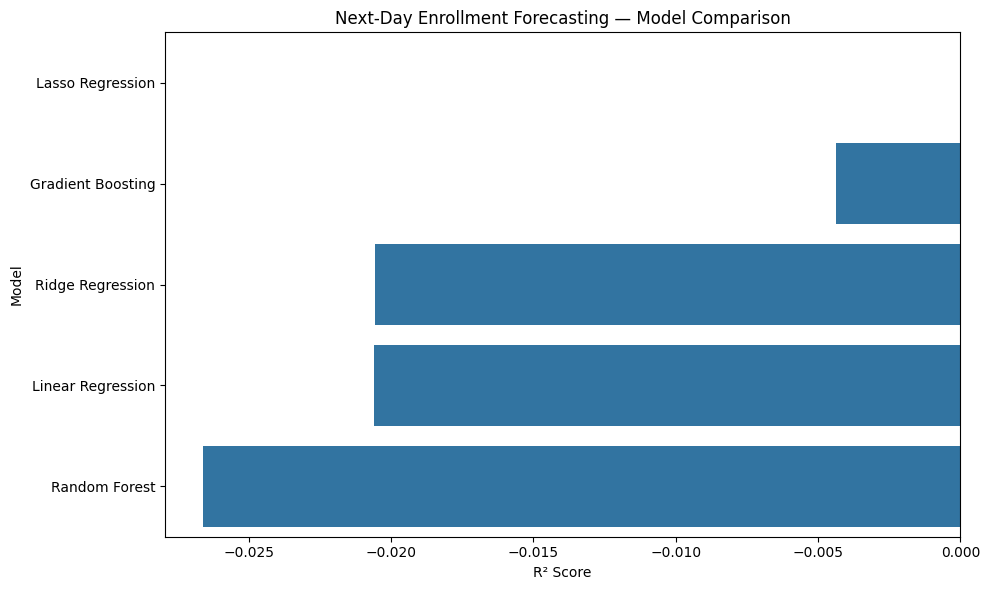

In [119]:
# Model Comparison Charts

plt.figure(figsize=(10, 6))

sns.barplot(
    data=enrollment_forecast_results_df,
    x="R2",
    y="Model"
)

plt.title(
    "Next-Day Enrollment Forecasting — Model Comparison"
)

plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

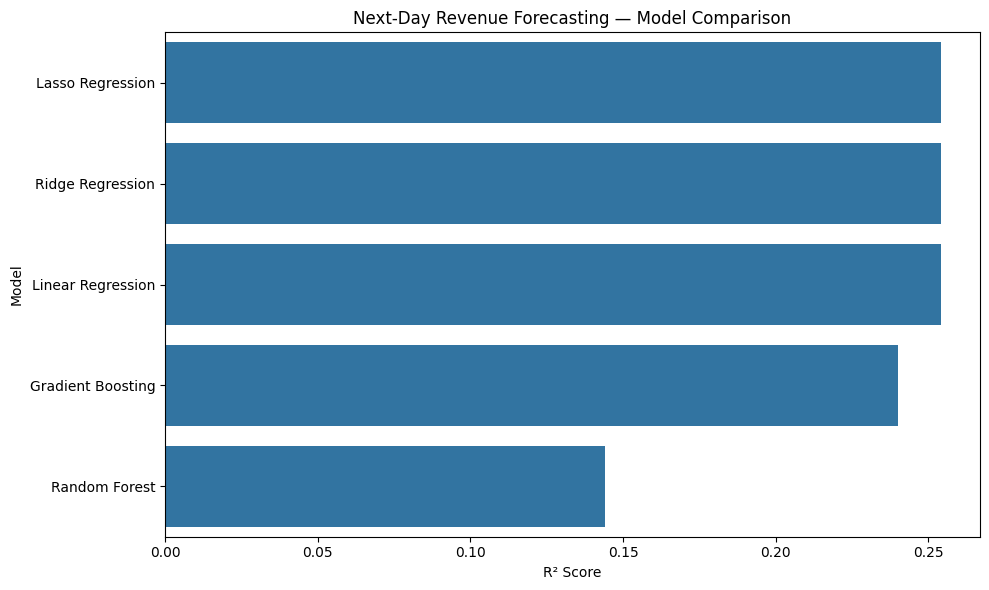

In [120]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_forecast_results_df,
    x="R2",
    y="Model"
)

plt.title(
    "Next-Day Revenue Forecasting — Model Comparison"
)

plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [121]:
# Select Best Models

best_enrollment_forecast_name = (
    enrollment_forecast_results_df
    .iloc[0]["Model"]
)

best_revenue_forecast_name = (
    revenue_forecast_results_df
    .iloc[0]["Model"]
)

best_enrollment_forecast_model = (
    enrollment_forecast_models[
        best_enrollment_forecast_name
    ]
)

best_revenue_forecast_model = (
    revenue_forecast_models[
        best_revenue_forecast_name
    ]
)

print(
    "Best Enrollment Forecast Model:",
    best_enrollment_forecast_name
)

print(
    "Best Revenue Forecast Model:",
    best_revenue_forecast_name
)

Best Enrollment Forecast Model: Lasso Regression
Best Revenue Forecast Model: Lasso Regression


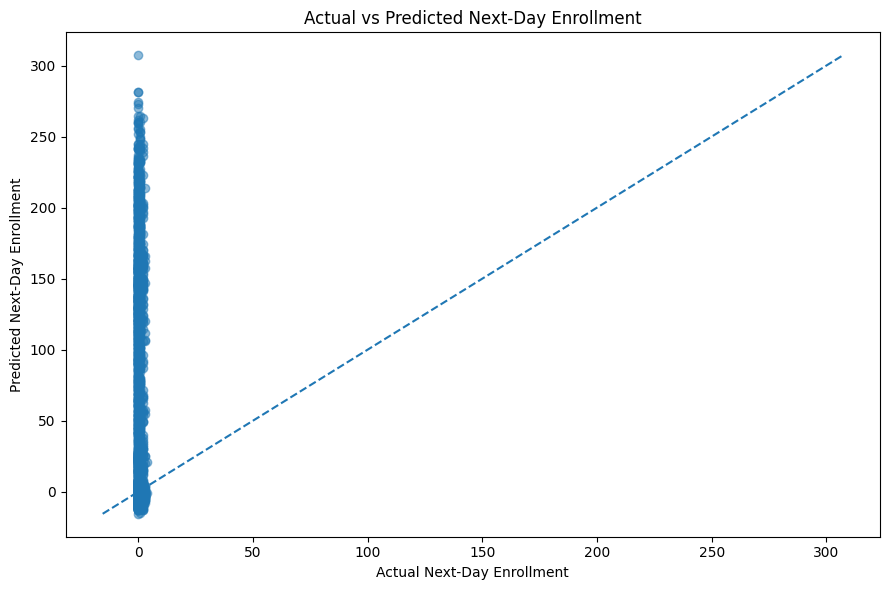

In [122]:
# Actual vs Predicted Enrollment

enrollment_test_predictions = (
    best_enrollment_forecast_model
    .predict(X_test)
)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_enrollment_test,
    enrollment_test_predictions,
    alpha=0.5
)

plt.xlabel("Actual Next-Day Enrollment")
plt.ylabel("Predicted Next-Day Enrollment")

plt.title(
    "Actual vs Predicted Next-Day Enrollment"
)

min_value = min(
    y_enrollment_test.min(),
    enrollment_test_predictions.min()
)

max_value = max(
    y_enrollment_test.max(),
    enrollment_test_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

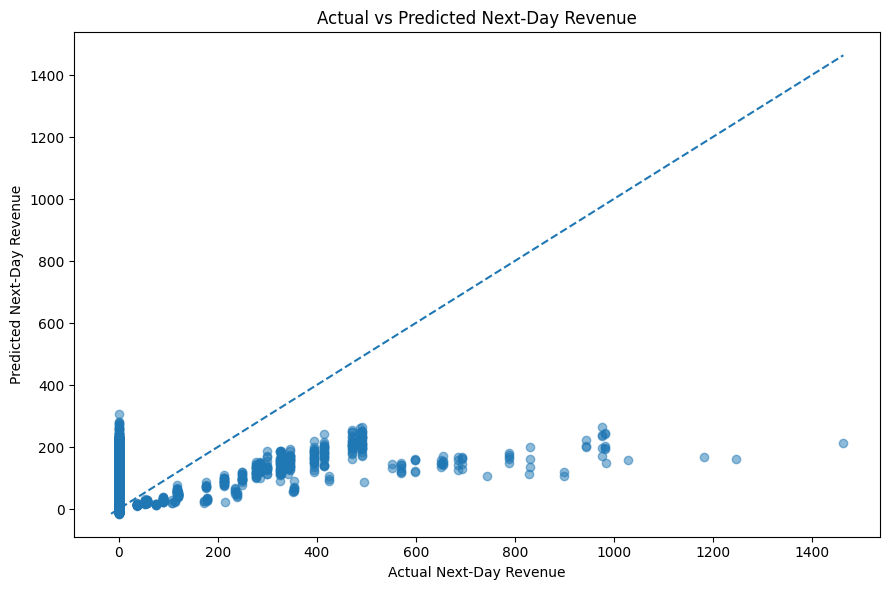

In [123]:
# Actual vs Predicted Revenue

revenue_test_predictions = (
    best_revenue_forecast_model
    .predict(X_test)
)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_revenue_test,
    revenue_test_predictions,
    alpha=0.5
)

plt.xlabel("Actual Next-Day Revenue")
plt.ylabel("Predicted Next-Day Revenue")

plt.title(
    "Actual vs Predicted Next-Day Revenue"
)

min_value = min(
    y_revenue_test.min(),
    revenue_test_predictions.min()
)

max_value = max(
    y_revenue_test.max(),
    revenue_test_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [124]:
# Forecast Results Table

forecast_predictions = test_data[
    [
        "Date",
        "CourseID",
        "CourseName",
        "CourseCategory"
    ]
].copy()

# Actual Enrollment
forecast_predictions[
    "Actual_Next_Day_Enrollment"
] = y_enrollment_test.values

# Predicted Enrollment
forecast_predictions[
    "Predicted_Next_Day_Enrollment"
] = np.maximum(0, enrollment_test_predictions)

# Actual Revenue
forecast_predictions[
    "Actual_Next_Day_Revenue"
] = y_revenue_test.values

# Predicted Revenue
forecast_predictions[
    "Predicted_Next_Day_Revenue"
] = np.maximum(0, revenue_test_predictions)

display(
    forecast_predictions.head(20)
)

,Date,CourseID,CourseName,CourseCategory,Actual_Next_Day_Enrollment,Predicted_Next_Day_Enrollment,Actual_Next_Day_Revenue,Predicted_Next_Day_Revenue
16020,2025-10-25,CR00051,HTML & CSS,Web Development,0.0,15.339776,0.00,15.339776
16021,2025-10-25,CR00029,Natural Language Processing,Machine Learning,0.0,0.000000,0.00,0.000000
16022,2025-10-25,CR00032,Ethical Hacking,Cybersecurity,1.0,0.000000,0.00,0.000000
16023,2025-10-25,CR00057,SEO for E-commerce,Digital Marketing,0.0,73.736346,0.00,73.736346
16024,2025-10-25,CR00050,Computer Vision,Artificial Intelligence,0.0,202.849910,0.00,202.849910
16025,2025-10-25,CR00020,Email Marketing,Marketing,2.0,0.000000,0.00,0.000000
16026,2025-10-25,CR00031,Network Security,Cybersecurity,0.0,0.000000,0.00,0.000000
16027,2025-10-25,CR00039,Project Planning,Project Management,1.0,139.678504,346.71,139.678504
16028,2025-10-25,CR00049,Deep Learning,Artificial Intelligence,0.0,195.122493,0.00,195.122493
16029,2025-10-25,CR00035,Cyber Threat Intelligence,Cybersecurity,1.0,0.000000,0.00,0.000000


In [125]:
# Prevent Negative Predictions (Regression models can sometimes produce negative values even though enrollments/revenue cannot be negative)

forecast_predictions[
    "Predicted_Next_Day_Enrollment"
] = forecast_predictions[
    "Predicted_Next_Day_Enrollment"
].clip(lower=0)

forecast_predictions[
    "Predicted_Next_Day_Revenue"
] = forecast_predictions[
    "Predicted_Next_Day_Revenue"
].clip(lower=0)

display(
    forecast_predictions.head()
)

,Date,CourseID,CourseName,CourseCategory,Actual_Next_Day_Enrollment,Predicted_Next_Day_Enrollment,Actual_Next_Day_Revenue,Predicted_Next_Day_Revenue
16020,2025-10-25,CR00051,HTML & CSS,Web Development,0.0,15.339776,0.0,15.339776
16021,2025-10-25,CR00029,Natural Language Processing,Machine Learning,0.0,0.000000,0.0,0.000000
16022,2025-10-25,CR00032,Ethical Hacking,Cybersecurity,1.0,0.000000,0.0,0.000000
16023,2025-10-25,CR00057,SEO for E-commerce,Digital Marketing,0.0,73.736346,0.0,73.736346
16024,2025-10-25,CR00050,Computer Vision,Artificial Intelligence,0.0,202.849910,0.0,202.849910


In [126]:
# Forecast by Category

category_forecast = (
    forecast_predictions
    .groupby("CourseCategory")
    .agg(
        Actual_Enrollment=(
            "Actual_Next_Day_Enrollment",
            "sum"
        ),

        Predicted_Enrollment=(
            "Predicted_Next_Day_Enrollment",
            "sum"
        ),

        Actual_Revenue=(
            "Actual_Next_Day_Revenue",
            "sum"
        ),

        Predicted_Revenue=(
            "Predicted_Next_Day_Revenue",
            "sum"
        )
    )
    .reset_index()
)

display(category_forecast)

,CourseCategory,Actual_Enrollment,Predicted_Enrollment,Actual_Revenue,Predicted_Revenue
0,Artificial Intelligence,157.0,34898.453398,38167.69,34898.453398
1,Business,150.0,32043.011318,30977.05,32043.011318
2,Cybersecurity,152.0,11039.651904,14587.62,11039.651904
3,Data Science,160.0,13562.959851,13105.90,13562.959851
4,Design,161.0,8136.414468,7738.36,8136.414468
5,Digital Marketing,143.0,10684.510590,8466.82,10684.510590
6,Finance,155.0,5039.435691,4883.74,5039.435691
7,Machine Learning,131.0,133.724401,16.38,133.724401
8,Marketing,159.0,205.751393,0.00,205.751393
9,Programming,145.0,14104.634481,12279.28,14104.634481


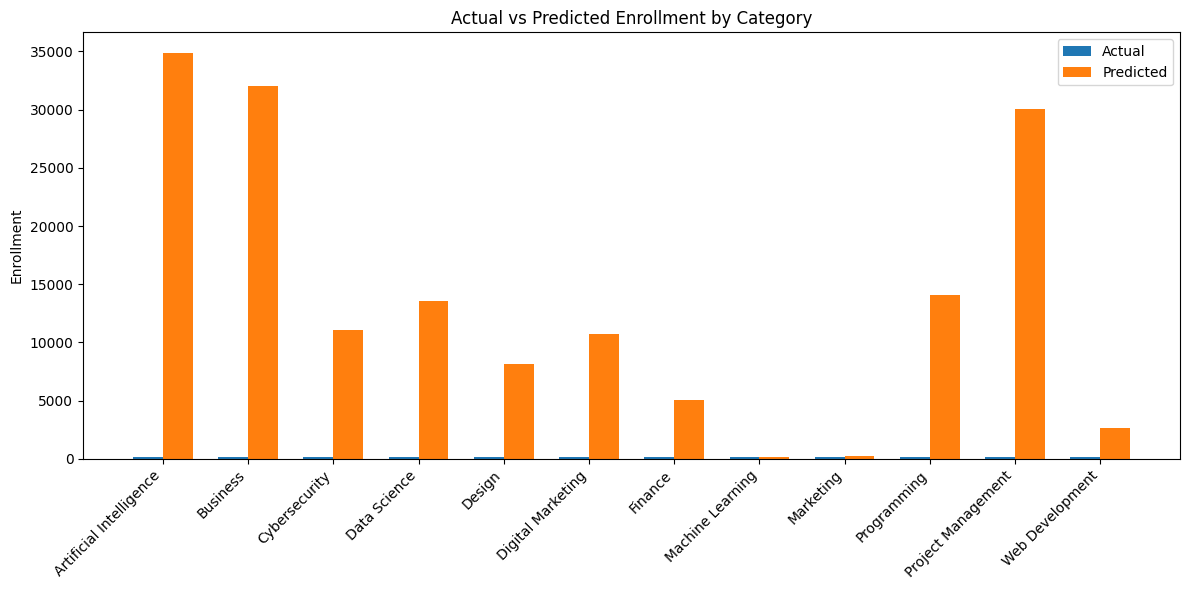

In [127]:
# Category Demand Forecast Chart

plt.figure(figsize=(12, 6))

x = np.arange(
    len(category_forecast)
)

width = 0.35

plt.bar(
    x - width / 2,
    category_forecast["Actual_Enrollment"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    category_forecast["Predicted_Enrollment"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    category_forecast["CourseCategory"],
    rotation=45,
    ha="right"
)

plt.ylabel("Enrollment")
plt.title(
    "Actual vs Predicted Enrollment by Category"
)

plt.legend()

plt.tight_layout()
plt.show()

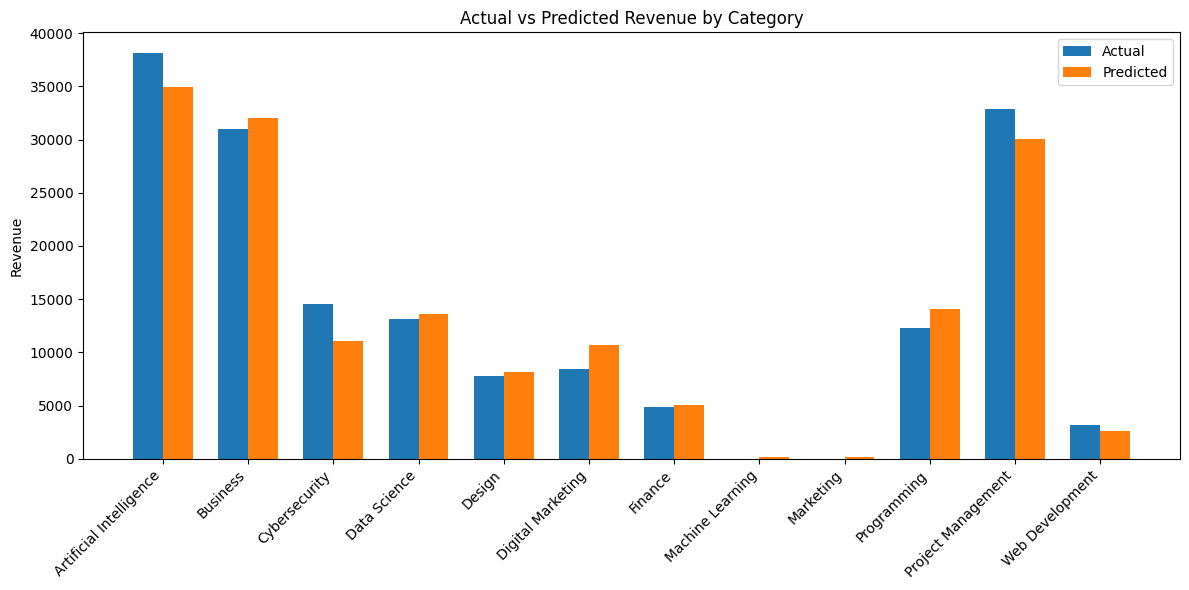

In [128]:
# Category Revenue Forecast

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    category_forecast["Actual_Revenue"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    category_forecast["Predicted_Revenue"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    category_forecast["CourseCategory"],
    rotation=45,
    ha="right"
)

plt.ylabel("Revenue")
plt.title(
    "Actual vs Predicted Revenue by Category"
)

plt.legend()

plt.tight_layout()
plt.show()

In [129]:
# Feature Importance

# Random Forest forecasting model
rf_forecast = enrollment_forecast_models[
    "Random Forest"
]

rf_preprocessor = (
    rf_forecast
    .named_steps["preprocessor"]
)

rf_model = (
    rf_forecast
    .named_steps["model"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df.head(20)
)

,Feature,Importance
0,num__CoursePrice,0.282324
1,num__WeekOfYear,0.082739
2,num__Revenue_Rolling_30,0.071569
3,num__Revenue_Rolling_14,0.061912
4,num__Revenue_Rolling_7,0.051324
5,num__DayOfWeek_Sin,0.050903
6,num__Enrollment_Rolling_30,0.038249
7,num__Revenue_Lag_30,0.033300
8,num__DayOfWeek_Cos,0.032581
9,num__Revenue_Growth,0.032273


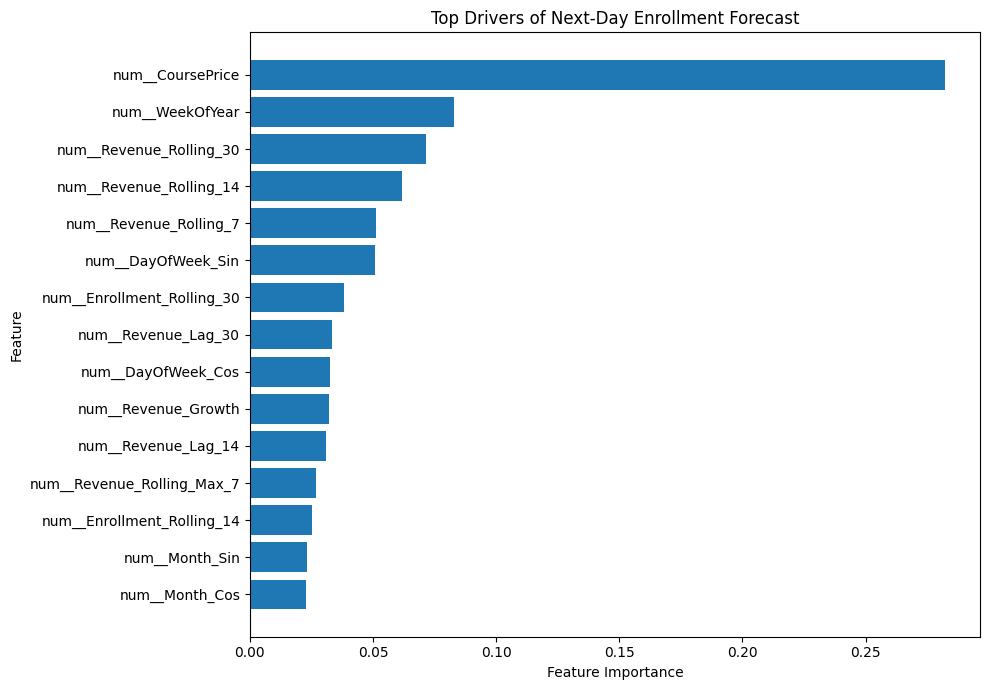

In [130]:
# Feature Importance Visualization

top_importance = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.title(
    "Top Drivers of Next-Day Enrollment Forecast"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [131]:
# Revenue Feature Importance

rf_revenue_forecast = revenue_forecast_models[
    "Random Forest"
]

revenue_rf_preprocessor = (
    rf_revenue_forecast
    .named_steps["preprocessor"]
)

revenue_rf_model = (
    rf_revenue_forecast
    .named_steps["model"]
)

revenue_feature_names = (
    revenue_rf_preprocessor
    .get_feature_names_out()
)

revenue_importance_df = pd.DataFrame({
    "Feature": revenue_feature_names,
    "Importance": revenue_rf_model.feature_importances_
})

revenue_importance_df = (
    revenue_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    revenue_importance_df.head(20)
)

,Feature,Importance
0,num__CoursePrice,0.282324
1,num__WeekOfYear,0.082739
2,num__Revenue_Rolling_30,0.071569
3,num__Revenue_Rolling_14,0.061912
4,num__Revenue_Rolling_7,0.051324
5,num__DayOfWeek_Sin,0.050903
6,num__Enrollment_Rolling_30,0.038249
7,num__Revenue_Lag_30,0.033300
8,num__DayOfWeek_Cos,0.032581
9,num__Revenue_Growth,0.032273


In [132]:
# Save Forecasting Results

forecast_predictions.to_csv(
    "EduPro_Next_Day_Forecast_Results.csv",
    index=False
)

category_forecast.to_csv(
    "EduPro_Category_Forecast.csv",
    index=False
)

enrollment_forecast_results_df.to_csv(
    "EduPro_Enrollment_Forecast_Model_Results.csv",
    index=False
)

revenue_forecast_results_df.to_csv(
    "EduPro_Revenue_Forecast_Model_Results.csv",
    index=False
)

importance_df.to_csv(
    "EduPro_Enrollment_Forecast_Feature_Importance.csv",
    index=False
)

revenue_importance_df.to_csv(
    "EduPro_Revenue_Forecast_Feature_Importance.csv",
    index=False
)

print("Forecasting result files saved.")

Forecasting result files saved.


In [133]:
# Save Final Forecasting Models

joblib.dump(
    best_enrollment_forecast_model,
    "EduPro_Next_Day_Enrollment_Model.pkl"
)

joblib.dump(
    best_revenue_forecast_model,
    "EduPro_Next_Day_Revenue_Model.pkl"
)

joblib.dump(
    forecast_features,
    "EduPro_Forecast_Features.pkl"
)

print("Forecasting models saved successfully.")

Forecasting models saved successfully.


In [134]:
# Final Model Report

print("=" * 80)
print("EDUPRO PREDICTIVE FORECASTING REPORT")
print("=" * 80)

print("\nENROLLMENT FORECASTING")
print("-" * 80)

display(
    enrollment_forecast_results_df
)

print(
    "\nBest Enrollment Forecast Model:",
    best_enrollment_forecast_name
)

print("\nREVENUE FORECASTING")
print("-" * 80)

display(
    revenue_forecast_results_df
)

print(
    "\nBest Revenue Forecast Model:",
    best_revenue_forecast_name
)

print("\nForecasting period:")
print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

EDUPRO PREDICTIVE FORECASTING REPORT

ENROLLMENT FORECASTING
--------------------------------------------------------------------------------


,Model,MAE,RMSE,R2
0,Lasso Regression,0.581417,0.677803,-2.961484e-09
1,Gradient Boosting,0.571633,0.679284,-4.376055e-03
2,Ridge Regression,0.557942,0.684733,-2.055404e-02
3,Linear Regression,0.557914,0.684751,-2.060569e-02
4,Random Forest,0.591869,0.686760,-2.660419e-02



Best Enrollment Forecast Model: Lasso Regression

REVENUE FORECASTING
--------------------------------------------------------------------------------


,Model,MAE,RMSE,R2
0,Lasso Regression,55.026893,117.744340,0.254187
1,Ridge Regression,55.148008,117.758813,0.254004
2,Linear Regression,55.148769,117.758907,0.254003
3,Gradient Boosting,53.734378,118.866852,0.239899
4,Random Forest,57.461317,126.138451,0.144057



Best Revenue Forecast Model: Lasso Regression

Forecasting period:
2025-10-25 00:00:00 to 2025-12-29 00:00:00


In [135]:
# Final Business Insight Generator

# Highest predicted enrollment category
highest_demand_category = (
    category_forecast
    .sort_values(
        "Predicted_Enrollment",
        ascending=False
    )
    .iloc[0]
)

# Highest predicted revenue category
highest_revenue_category = (
    category_forecast
    .sort_values(
        "Predicted_Revenue",
        ascending=False
    )
    .iloc[0]
)

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print(
    "\nCategory with highest predicted enrollment:"
)

print(
    highest_demand_category[
        "CourseCategory"
    ]
)

print(
    "Predicted enrollment:",
    round(
        highest_demand_category[
            "Predicted_Enrollment"
        ],
        2
    )
)

print(
    "\nCategory with highest predicted revenue:"
)

print(
    highest_revenue_category[
        "CourseCategory"
    ]
)

print(
    "Predicted revenue:",
    round(
        highest_revenue_category[
            "Predicted_Revenue"
        ],
        2
    )
)

BUSINESS INSIGHTS

Category with highest predicted enrollment:
Artificial Intelligence
Predicted enrollment: 34898.45

Category with highest predicted revenue:
Artificial Intelligence
Predicted revenue: 34898.45


In [136]:
# Export Final Master Dataset

forecast_data.to_csv(
    "EduPro_Final_Forecasting_Dataset.csv",
    index=False
)

print(
    "Final forecasting dataset exported successfully."
)

Final forecasting dataset exported successfully.


# Dashboard:

In [137]:
import os
print(os.getcwd())

C:\Users\preks\OneDrive\Desktop\Edupro Online Platform


In [138]:
import os
import zipfile

csv_files = [
    file for file in os.listdir()
    if file.endswith(".csv") and file.startswith("EduPro_")
]

with zipfile.ZipFile(
    "EduPro_CSV_Files.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    
    for file in csv_files:
        zipf.write(file)

print("✅ EduPro_CSV_Files.zip created successfully!")

✅ EduPro_CSV_Files.zip created successfully!


In [139]:
# Saari generated files identify karo
import os

for file in os.listdir():
    if file.endswith((".csv", ".pkl")):
        print(file)

EduPro_Category_Forecast - Copy.csv
EduPro_Category_Forecast.csv
EduPro_Category_Summary.csv
EduPro_Course_Level_Processed.csv
EduPro_Enrollment_Feature_Importance.csv
EduPro_Enrollment_Forecast_Feature_Importance.csv
EduPro_Enrollment_Forecast_Model_Results.csv
EduPro_Enrollment_Model.pkl
EduPro_Enrollment_Model_Results.csv
EduPro_Final_Forecasting_Dataset.csv
EduPro_Forecast_Features.pkl
EduPro_Model_Metadata.pkl
EduPro_Next_Day_Enrollment_Model.pkl
EduPro_Next_Day_Forecast_Results.csv
EduPro_Next_Day_Revenue_Model.pkl
EduPro_Revenue_Feature_Importance.csv
EduPro_Revenue_Forecast_Feature_Importance.csv
EduPro_Revenue_Forecast_Model_Results.csv
EduPro_Revenue_Model.pkl
EduPro_Revenue_Model_Results.csv
